# PHASE 1 — Business Understanding 
Business Problem

Business Objectives

Questions to Answer

# PHASE 2 — Dataset Understanding 

Dataset Overview

Columns

Data Types

Data Dictionary

Initial Observations

## DATA STUDY

• Imported Pandas for data loading, manipulation, and analysis.

• Imported NumPy for numerical computations and handling missing values in later stages.

• These libraries form the foundation of our data analysis workflow.

In [1]:
import numpy as np
import pandas as pd 

• Successfully loaded the Online Retail II dataset into a Pandas DataFrame.
• The dataset is now ready for exploration and quality assessment.
• No preprocessing has been performed at this stage.

In [2]:
df=pd.read_excel('online_retail_II.xlsx')

In [3]:
df.shape

(525461, 8)

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [6]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

• Identified the data types of all columns.
• Observed that Quantity is stored as an integer and Price as a floating-point number.
• InvoiceDate is stored as a datetime column, making time-based analysis possible.
• Customer ID contains missing values and will require further investigation.
• Memory usage appears reasonable for analysis using Pandas.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(6865)

In [10]:
(df['Price']<=0).sum()


np.int64(3690)

In [11]:
(df['Quantity']<=0).sum()


np.int64(12326)

In [12]:
df[df['Price']<=0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [13]:
df[df['Quantity']<=0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [14]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [15]:
df.describe(include='object')

,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [16]:
df['Country'].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Nigeria',
       'Netherlands', 'Poland', 'Spain', 'Channel Islands', 'Italy',
       'Cyprus', 'Greece', 'Norway', 'Austria', 'Sweden',
       'United Arab Emirates', 'Finland', 'Switzerland', 'Unspecified',
       'Malta', 'Bahrain', 'RSA', 'Bermuda', 'Hong Kong', 'Singapore',
       'Thailand', 'Israel', 'Lithuania', 'West Indies', 'Lebanon',
       'Korea', 'Brazil', 'Canada', 'Iceland'], dtype=object)

In [17]:
df['Country'].nunique()

40

In [18]:
df['Customer ID'].nunique()

4383

In [19]:
df['Invoice'].nunique()

28816

In [20]:
df['Description'].nunique()

4681

In [21]:
df['Country'].value_counts()

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [22]:
df['Quantity'].value_counts().head(10)

Quantity
1     146118
2      78131
12     60682
6      44431
3      35517
4      33898
24     23015
10     18668
8      12690
5      11408
Name: count, dtype: int64

# PHASE 3 — Data Cleaning & Investigation

Instead of blindly cleaning, we investigated.

Missing Values

✅ Customer ID
✅ Description
Duplicates

✅ Investigated
✅ Removed
Negative Quantity

✅ Found they represent returns/cancellations
✅ Kept separately for future return analysis
Price = 0

✅ Investigated
✅ Removed only from customer analysis dataset
Feature Engineering

✅ Revenue
✅ Year
✅ Month
✅ Month Name
✅ YearMonth

In [23]:
df['Revenue']=df['Quantity']*df['Price']

In [24]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [25]:
df['Revenue'].describe()

count    525461.000000
mean         18.154506
std         160.333083
min      -53594.360000
25%           3.750000
50%           9.950000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64

In [26]:
df['Revenue'].sum()

np.float64(9539484.634)

In [27]:
df['Revenue'].mean()

np.float64(18.15450553704271)

In [28]:
df['Revenue'].max()

25111.09

In [29]:
df['Revenue'].min()

-53594.36

In [30]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(1)


Country
United Kingdom    8194777.533
Name: Revenue, dtype: float64

## 📍Step 1 — Make a Copy

Rule #1 in every company.

Never modify the original dataset.


• Created a copy of the original dataset before performing any cleaning operations.
• This ensures the raw dataset remains unchanged and allows us to compare cleaned and original data whenever required.

In [31]:
df_clean=df.copy()

In [32]:
df_clean['Customer ID'].isnull().sum()

np.int64(107927)

## Investigation 1 — Missing Customer ID

In [33]:
df[df['Customer ID'].isnull()].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,-0.00
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,-0.00
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,0.55


### Explanation ^
These are not incomplete transactions.

These are complete sales transactions where the customer identity is unknown.


If we simply removed them without understanding them, we'd lose genuine sales data.

In [34]:
df[df['Customer ID'].isnull()]['Country'].value_counts()

Country
United Kingdom          106429
EIRE                       960
United Arab Emirates       114
Portugal                    77
Hong Kong                   76
Bahrain                     65
France                      62
RSA                         46
Bermuda                     34
Unspecified                 30
Sweden                      19
Lebanon                     13
Nigeria                      2
Name: count, dtype: int64

In [35]:
df[df['Customer ID'].isnull()]['Price'].describe()

count    107927.000000
mean          7.788750
std         290.474071
min      -53594.360000
25%           1.660000
50%           3.360000
75%           5.910000
max       25111.090000
Name: Price, dtype: float64

In [36]:
df[df['Customer ID'].isnull()][['Price','Revenue']].describe()

,Price,Revenue
count,107927.000000,107927.000000
mean,7.788750,11.037795
std,290.474071,294.062449
min,-53594.360000,-53594.360000
25%,1.660000,2.510000
50%,3.360000,5.060000
75%,5.910000,10.180000
max,25111.090000,25111.090000


## Investigation 2 — Negative Quantity

In [37]:
negative=df[df['Quantity']<0]

In [38]:
negative[['Invoice','Quantity','Price','Description','Customer ID']].head(20)


,Invoice,Quantity,Price,Description,Customer ID
178,C489449,-12,2.95,PAPER BUNTING WHITE LACE,16321.0
179,C489449,-6,1.65,CREAM FELT EASTER EGG BASKET,16321.0
180,C489449,-4,4.25,POTTING SHED SOW 'N' GROW SET,16321.0
181,C489449,-6,2.10,POTTING SHED TWINE,16321.0
182,C489449,-12,2.95,PAPER CHAIN KIT RETRO SPOT,16321.0
183,C489449,-12,1.25,SAVE THE PLANET MUG,16321.0
184,C489449,-12,1.25,ANTIQUE SILVER TEA GLASS ETCHED,16321.0
185,C489449,-24,0.85,HANGING HEART ZINC T-LIGHT HOLDER,16321.0
186,C489449,-12,2.95,PAPER BUNTING RETRO SPOTS,16321.0
196,C489459,-3,4.25,PURPLE SWEETHEART BRACELET,17592.0


## Investigation 3 — Price ≤ 0

In [39]:
price = df[df['Price'] <= 0]
price[['Invoice', 'Quantity', 'Price', 'Description', 'Customer ID']].head(20)


,Invoice,Quantity,Price,Description,Customer ID
263,489464,-96,0.0,85123a mixed,NaN
283,489463,-240,0.0,short,NaN
284,489467,-192,0.0,21733 mixed,NaN
470,489521,-50,0.0,NaN,NaN
3114,489655,-44,0.0,NaN,NaN
3161,489659,230,0.0,NaN,NaN
3162,489660,-1043,0.0,lost,NaN
3168,489663,-117,0.0,damages,NaN
3731,489781,17,0.0,NaN,NaN
4296,489806,-770,0.0,NaN,NaN


## Investigation 4 — Duplicates

In [40]:
dup=df[df.duplicated(keep=False)]
dup.sort_values(by='Invoice').head(10)

TypeError: '<' not supported between instances of 'str' and 'int'

In [41]:
# 2. Convert Invoice to string type to allow sorting mixed types
dup['Invoice']=dup['Invoice'].astype(str)

C:\Users\kprsv\AppData\Local\Temp\ipykernel_17116\4200842846.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dup['Invoice']=dup['Invoice'].astype(str)


In [42]:
dup.sort_values(by='Invoice').head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,1.95
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom,2.55
388,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01 11:34:00,2.55,16329.0,United Kingdom,2.55
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom,7.80
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,1.95
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,3.75


## Cleaning Strategy

| Data Issue          | Investigation Result                                                    | Decision                                                           |
| ------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------ |
| Missing Customer ID | Valid transactions but anonymous                                        | Keep in raw dataset. Exclude only from customer analytics dataset. |
| Negative Quantity   | Likely returns/cancellations                                            | Keep separately as a returns dataset. Don't blindly delete.        |
| Price = 0           | Mixed cases (inventory adjustments, operational entries, some products) | Investigate/categorize before deciding. Don't remove blindly.      |
| Duplicate Rows      | Exact duplicate records                                                 | Remove from cleaned dataset.                                       |


## Create Separate Datasets


| Dataset     | Purpose                         |
| ----------- | ------------------------------- |
| df          | Raw backup                      |
| customer_df | RFM, CLV, Customer Segmentation |
| returns_df  | Return Behaviour Analysis       |
| sales_df    | Revenue & Sales Dashboard       |


In [43]:
#original dataset  -> df (dont touch)

#Customer Analytics Dataset
customer_df=df.copy()

# Return/Cancellation Dataset
return_df=df[df['Invoice'].astype(str).str.startswith('C')].copy()

#Sales Dataset 
sales_df=df.copy()

## Step 1 — Customer Analytics Dataset

goal:I want to study customer behaviour

Can we study a customer without Customer ID?

No.

So NOW (and only now) remove missing Customer IDs.

In [44]:
customer_df.shape

(525461, 9)

Why did you use subset?

A good answer is:

"Because I wanted to remove rows only where Customer ID is missing. Other missing values, such as Description, may still contain useful business information, so I didn't want to remove rows based on all columns

In [45]:
customer_df.dropna(subset=['Customer ID'],inplace=True)

In [46]:
customer_df.shape

(417534, 9)

In [47]:
customer_df['Customer ID'].isnull().sum()

np.int64(0)

## Remove Exact Duplicates

In [48]:
customer_df.duplicated().sum()

np.int64(6771)

In [49]:
customer_df.drop_duplicates(inplace=True)

In [50]:
customer_df.duplicated().sum()

np.int64(0)

Business Observation 

Observation: Exact duplicate records were removed because they represented repeated entries of the same transaction. Keeping them would artificially inflate business metrics such as revenue, order count, product demand, and customer spending.

In [51]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Decision: Price = 0 rows are retained because the investigation showed they represent mixed business events (inventory adjustments, operational records, postage, etc.). Without business confirmation, removing them may lead to loss of valid information.

## EDA (Exploratory Data Analysis)

### Step 1: Understand the cleaned dataset

In [52]:
customer_df.shape

(410763, 9)

In [53]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410763 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      410763 non-null  object        
 1   StockCode    410763 non-null  object        
 2   Description  410763 non-null  object        
 3   Quantity     410763 non-null  int64         
 4   InvoiceDate  410763 non-null  datetime64[ns]
 5   Price        410763 non-null  float64       
 6   Customer ID  410763 non-null  float64       
 7   Country      410763 non-null  object        
 8   Revenue      410763 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.3+ MB


In [54]:
customer_df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,410763.000000,410763,410763.000000,410763.000000,410763.000000
mean,12.923735,2010-06-30 19:56:14.853674752,3.908358,15353.621857,20.242465
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000,-25111.090000
25%,2.000000,2010-03-26 09:46:00,1.250000,13979.000000,4.500000
50%,5.000000,2010-07-08 15:09:00,1.950000,15311.000000,11.800000
75%,12.000000,2010-10-14 12:32:00,3.750000,16797.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,15818.400000
std,102.039550,NaN,71.714794,1681.657665,100.710825


In [55]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# PHASE 4 — KPI Analysis 

### Step 2: Basic KPIs

Total Revenue,
Total Orders,
Total Customers,
Average Order Value (AOV),
Total Products Sold




#### (Simple Total Revenue)

In [56]:
total_revenue=customer_df['Revenue'].sum()
# print("Total_revenue:","$",total_revenue)
print(f"Total_revenue:${total_revenue:,.2f}")

Total_revenue:$8,314,855.58


#### Total Orders

In [57]:
Total_order=customer_df["Invoice"].nunique()
print(Total_order)

23587


#### Country-wise Total Order

In [58]:
to=customer_df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False)
to.head()


Country
United Kingdom    21481
Germany             513
EIRE                418
France              292
Netherlands         150
Name: Invoice, dtype: int64

#### Total Customers

In [59]:
cus=customer_df["Customer ID"].nunique()
print(cus)

4383


#### Coutry wise Total Customers

In [60]:
tc=customer_df.groupby("Country")["Customer ID"].nunique().sort_values(ascending=False)

tc.head()

Country
United Kingdom    4035
Germany             68
France              47
Spain               25
Netherlands         23
Name: Customer ID, dtype: int64

#### Average Order Value (AOV)

To calculate the Average Order Value (AOV), you need to divide your Total Revenue by the Total Number of Unique Orders

In [61]:
Total_aov=total_revenue/Total_order
print(Total_aov)

352.51857311230765


#### country wise Average Order Value (AOV)

In [62]:
country_aov = (customer_df.groupby("Country")["Revenue"].sum()
    /
    customer_df.groupby("Country")["Invoice"].nunique()
)

country_aov.sort_values(ascending=False).head()

Country
Netherlands    1759.078400
Israel         1599.700000
Thailand       1535.270000
Denmark        1423.422727
Singapore      1009.442500
dtype: float64

####  Total Products Sold

In [63]:
# Filter for positive quantities only
positive_sales = customer_df[customer_df["Quantity"] > 0]

# Grand Gross Total
gross_total = positive_sales["Quantity"].sum()
print(gross_total)


5520448


#### Country-wise Gross Total


In [64]:
positive_sales.groupby("Country")["Quantity"].sum().sort_values(ascending=False)


Country
United Kingdom          4430926
Denmark                  229690
Netherlands              183679
EIRE                     181413
France                   162048
Germany                  108633
Sweden                    52417
Spain                     22841
Switzerland               22255
Australia                 20189
Belgium                   12069
Channel Islands           11991
Portugal                  11988
Norway                     7867
Italy                      7364
Japan                      7311
Austria                    6697
Greece                     6167
United Arab Emirates       4857
Cyprus                     4610
Finland                    3671
Unspecified                3328
USA                        2806
Thailand                   2552
Lithuania                  2306
Poland                     2144
Singapore                  1753
Malta                      1549
Israel                     1132
Canada                      894
Iceland                     828


### Step 3: First Visualization

We'll answer:

How has revenue changed over time?

#### Step-1 Extract Date Information

In [65]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [66]:
customer_df["InvoiceDate"]

0        2009-12-01 07:45:00
1        2009-12-01 07:45:00
2        2009-12-01 07:45:00
3        2009-12-01 07:45:00
4        2009-12-01 07:45:00
                 ...        
525456   2010-12-09 20:01:00
525457   2010-12-09 20:01:00
525458   2010-12-09 20:01:00
525459   2010-12-09 20:01:00
525460   2010-12-09 20:01:00
Name: InvoiceDate, Length: 410763, dtype: datetime64[ns]

In [67]:
customer_df["Year"]=customer_df["InvoiceDate"].dt.year
customer_df["Month"]=customer_df["InvoiceDate"].dt.month
customer_df['Month_Name'] = customer_df['InvoiceDate'].dt.month_name()

#### Step 2 — Monthly Revenue

In [68]:
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December


In [69]:
monthly_rev=customer_df.groupby(["Year","Month"])["Revenue"].sum()
print(monthly_rev)

Year  Month
2009  12        660125.100
2010  1         530436.512
      2         487596.426
      3         633419.311
      4         558007.832
      5         557873.390
      6         568784.550
      7         560885.330
      8         585259.460
      9         778520.051
      10        961520.740
      11       1129025.162
      12        303401.720
Name: Revenue, dtype: float64


#### Country wise monthly revenue

In [70]:
country_monthrev=customer_df.groupby(["Country","Month_Name"])["Revenue"].sum()
print(country_monthrev)



Country      Month_Name
Australia    April          630.95
             August         176.00
             December       667.40
             February      1029.66
             July           633.62
                            ...   
Unspecified  January        998.35
             July          1189.94
             November       300.93
             September     1967.95
West Indies  August         536.41
Name: Revenue, Length: 268, dtype: float64


# PHASE 5 — Revenue Trend Analysis

#### Step 3 — Plot

Create a simple line chart.

Plot:

x-axis → Month

y-axis → Revenue

In [71]:
# Create YearMonth:
customer_df["YearMonth"]=customer_df["InvoiceDate"].dt.to_period("M")

# Calculate monthly revenue:
monthly=customer_df.groupby("YearMonth")["Revenue"].sum()
print(monthly)


YearMonth
2009-12     660125.100
2010-01     530436.512
2010-02     487596.426
2010-03     633419.311
2010-04     558007.832
2010-05     557873.390
2010-06     568784.550
2010-07     560885.330
2010-08     585259.460
2010-09     778520.051
2010-10     961520.740
2010-11    1129025.162
2010-12     303401.720
Freq: M, Name: Revenue, dtype: float64


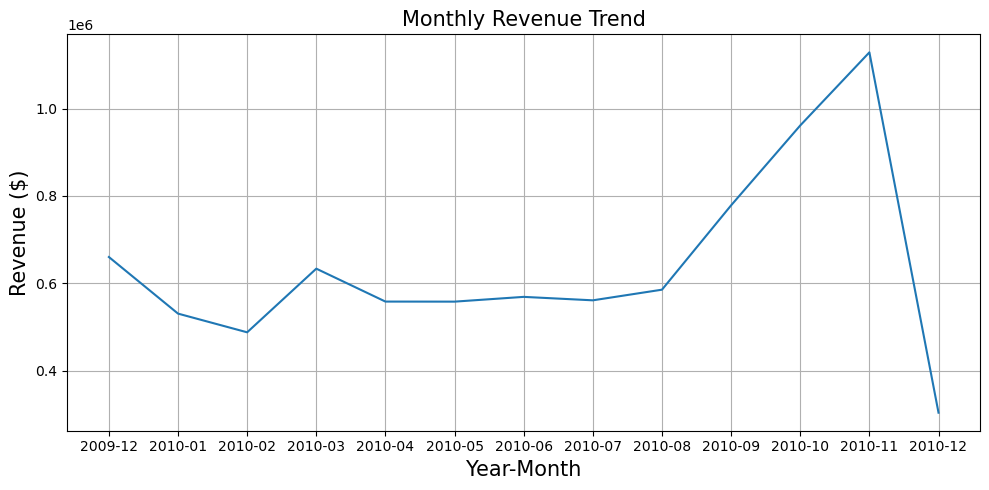

In [72]:
# Now plot monthly_revenue
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(monthly.index.astype(str),monthly.values)
plt.title("Monthly Revenue Trend",fontsize=15)
plt.xlabel("Year-Month",fontsize=15)
plt.ylabel("Revenue ($)",fontsize=15)
plt.tight_layout()  
plt.grid(True)
plt.show()

#### Observations
1.Revenue reached its highest level in November 2010, making it the best-performing month in the given time period.

2.Revenue was at its lowest in December 2010, showing a sharp decline compared to November 2010.

3.Overall, the company experienced an upward revenue trend throughout the observed period, indicating business growth despite some month-to-month fluctuations.

4.A significant spike in revenue is observed in November 2010, suggesting the impact of seasonal demand, promotional campaigns, or an increase in customer purchases. Further investigation is required to identify the exact reason.

5.A sharp decline in revenue is observed in December 2010. Based on the graph alone, the exact cause cannot be determined. Additional analysis of order volume, customer count, average order value, and products sold is required before drawing any business conclusion.

## Q1.Our question is: Why did November 2010 have the highest revenue?

We'll investigate like detectives.

Investigation 1: Were there more orders?

In [73]:
monthly_orders=customer_df.groupby("YearMonth")["Invoice"].nunique()
monthly_orders

YearMonth
2009-12    1900
2010-01    1296
2010-02    1335
2010-03    1907
2010-04    1615
2010-05    1768
2010-06    1833
2010-07    1713
2010-08    1547
2010-09    2041
2010-10    2586
2010-11    3145
2010-12     901
Freq: M, Name: Invoice, dtype: int64

Observation: (Were there more orders? Yes) The number of unique orders reached its highest level in November 2010 (3,145 orders). This indicates that one of the primary reasons for the revenue spike in November was a significant increase in customer orders.

In [74]:
monthly_cus=customer_df.groupby("YearMonth")["Customer ID"].nunique()
monthly_cus

YearMonth
2009-12    1045
2010-01     786
2010-02     807
2010-03    1111
2010-04     998
2010-05    1062
2010-06    1095
2010-07     988
2010-08     964
2010-09    1202
2010-10    1577
2010-11    1683
2010-12     622
Freq: M, Name: Customer ID, dtype: int64

#### Business Investigation:

Revenue increased in November 2010

        │
        ├── Highest number of Orders ✅ (3,145)
        └── Highest number of Unique Customers ✅
📝 Observation

Observation: November 2010 recorded the highest number of unique customers, indicating increased customer engagement during this period. The simultaneous rise in both customer count and order volume strongly contributed to the highest monthly revenue observed in November 2010.

In [75]:
monthly_revenue=customer_df.groupby("YearMonth")["Revenue"].sum()
monthly_orders=customer_df.groupby("YearMonth")["Invoice"].nunique()

monthly_aov=monthly_revenue/monthly_orders
monthly_aov

YearMonth
2009-12    347.434263
2010-01    409.287432
2010-02    365.240769
2010-03    332.154856
2010-04    345.515685
2010-05    315.539248
2010-06    310.302537
2010-07    327.428681
2010-08    378.318979
2010-09    381.440495
2010-10    371.817765
2010-11    358.990513
2010-12    336.738868
Freq: M, dtype: float64

-----------------------------------------------------------------

### OBSERVATION:
Highest Revenue (Nov 2010)

        │
        ├── Highest Orders ✅
        ├── Highest Customers ✅
        └── NOT Highest AOV ❌
Polished Observation

Observation: Although November 2010 recorded the highest monthly revenue, it did not have the highest Average Order Value (AOV). Instead, January 2010 had the highest AOV, indicating that customers spent more per order in January. Therefore, the revenue growth in November was primarily driven by a higher number of customers placing more orders, rather than customers spending significantly more per transaction.

In [76]:
monthly_products=customer_df[customer_df["Quantity"]>0].groupby("YearMonth")["Quantity"].sum()

monthly_products

YearMonth
2009-12    398708
2010-01    370128
2010-02    371871
2010-03    502101
2010-04    350604
2010-05    384960
2010-06    389880
2010-07    324638
2010-08    452551
2010-09    567806
2010-10    596497
2010-11    653074
2010-12    157630
Freq: M, Name: Quantity, dtype: int64

# PHASE 6 — Country Analysis

### Q2. Which countries contribute the most to the business?

#### Analysis 1 — Revenue by Country
Plot a horizontal bar chart (Top 10 countries).

Write 4–5 observations.

Give 1 business recommendation.


In [77]:
cr=customer_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
cr.head(10)



Country
United Kingdom    7005793.443
EIRE               328234.260
Netherlands        263861.760
Germany            195920.421
France             129665.480
Sweden              50836.110
Denmark             46972.950
Switzerland         43343.410
Spain               37052.130
Australia           30051.800
Name: Revenue, dtype: float64

Observations:

United Kingdom contributes the highest revenue (~₹7.01M), indicating it is the company's primary market.
EIRE and the Netherlands are the next largest revenue contributors but are significantly smaller than the UK.
Revenue is highly concentrated in a few countries, suggesting opportunities to expand sales in underperforming regions.

#### Top 10 Countries

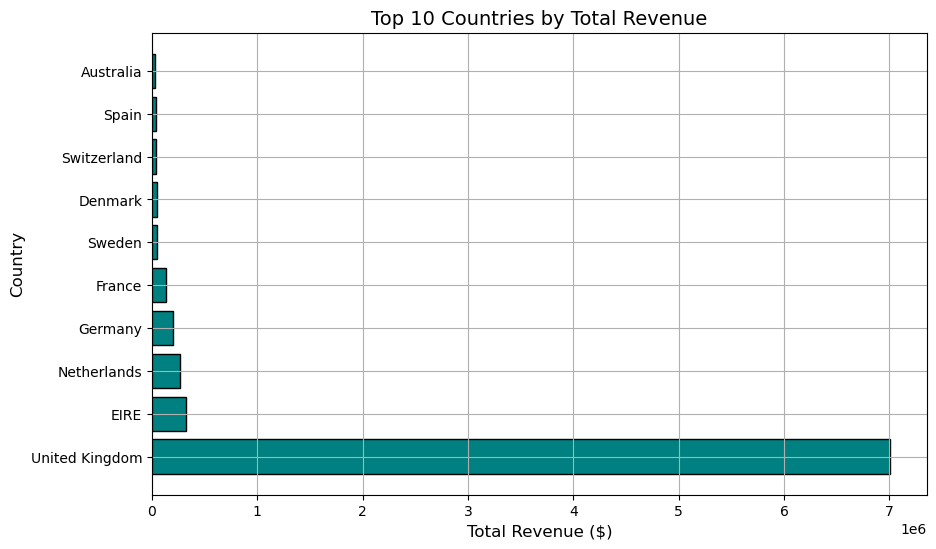

In [78]:
top10 = customer_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10.values, color="teal", edgecolor="black")
plt.title("Top 10 Countries by Total Revenue", fontsize=14)
plt.xlabel("Total Revenue ($)", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(True)
plt.show()

### OUTCOME:

📊 Observations 
1.The United Kingdom is the dominant market, contributing the highest share of total revenue by a significant margin. This indicates that the company's business is heavily dependent on the UK market.

2.EIRE and the Netherlands are the second and third highest revenue-generating countries, but their contribution is substantially lower than that of the UK.

3.Germany and France also contribute a considerable amount of revenue, indicating a strong customer base in these European markets.

4.The remaining countries contribute relatively small portions of total revenue, suggesting that the company's international sales are concentrated in only a few key markets.

5. Among the Top 10 countries, Australia contributes the lowest revenue.


💼 Business Recommendation

Your recommendation is good, but let's make it more business-oriented.

Recommendation: Since EIRE, the Netherlands, Germany, and France already generate considerable revenue, the company should invest in targeted marketing campaigns, loyalty programs, and region-specific promotional offers to strengthen customer retention and further increase sales in these high-potential markets. At the same time, the company should avoid over-reliance on the UK by gradually expanding its presence in other profitable regions.

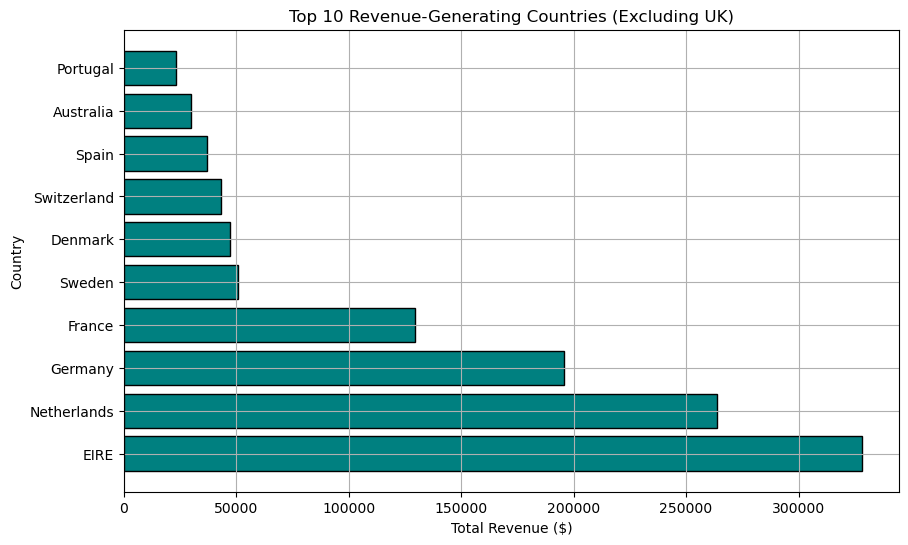

In [79]:
country_revenue = customer_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_revenue_no_uk = country_revenue.drop("United Kingdom")
top10_no_uk = country_revenue_no_uk.head(10)
plt.figure(figsize=(10,6))

plt.barh(top10_no_uk.index,
         top10_no_uk.values,
         color="teal",
         edgecolor="black")

plt.title("Top 10 Revenue-Generating Countries (Excluding UK)")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Country")

plt.grid(True)
plt.show()

### Analysis 2 — Orders by Country

Again:

Horizontal bar chart

Observations

Recommendation

Question to answer:

Q1->Is UK's high revenue because of more orders? (YES)

Q2->Is UK's high revenue because of more Highest Customers  (YES)

Q3->Is UK's high revenue because of more Highest AOV  (No)

Q4->Is UK's high revenue because of more Highest Products Sold  (yes)

MAX ORDER

In [80]:
max_orders=customer_df.groupby("Country")["Invoice"].nunique().sort_values(ascending=False).head(10)
max_orders

Country
United Kingdom    21481
Germany             513
EIRE                418
France              292
Netherlands         150
Spain                85
Sweden               82
Belgium              65
Portugal             56
Switzerland          50
Name: Invoice, dtype: int64

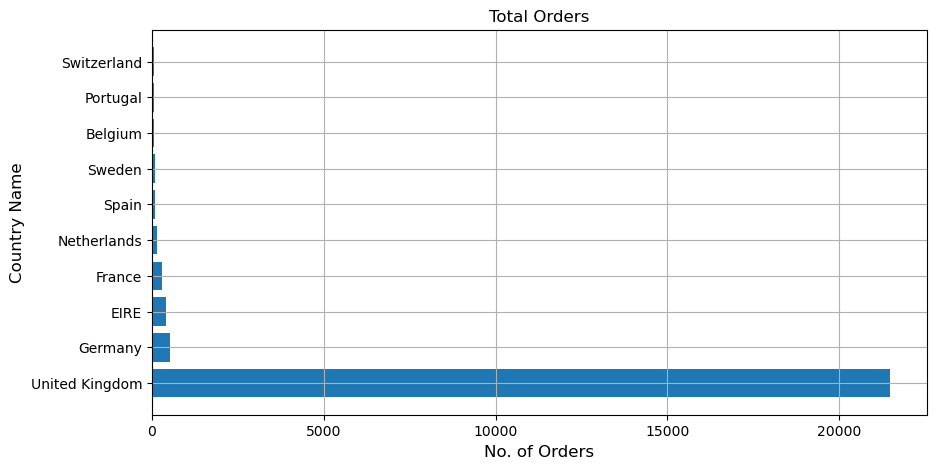

In [81]:
plt.figure(figsize=(10,5))
plt.barh(max_orders.index,max_orders.values)
plt.title("Total Orders",fontsize=12)
plt.xlabel("No. of Orders",fontsize=12)
plt.ylabel("Country Name",fontsize=12)
plt.grid(True)
plt.show()

### Observations:
1.The United Kingdom recorded the highest number of orders among all countries.

2.Germany and EIRE are the next highest contributors in terms of order count, although they are significantly behind the UK.

3.The large gap between the UK and other countries suggests that the company's operations are heavily concentrated in the UK market.

💼 Business Recommendation

Since the UK generates both the highest revenue and the highest number of orders, the company should continue strengthening customer retention through loyalty programs and personalized marketing. At the same time, similar customer acquisition strategies can be implemented in high-potential markets such as Germany and EIRE to increase order volume and reduce dependence on a single market.

Highest Customers

In [82]:
max_cus=customer_df.groupby("Country")["Customer ID"].nunique().sort_values(ascending=False).head(10)
max_cus

Country
United Kingdom    4035
Germany             68
France              47
Spain               25
Netherlands         23
Portugal            18
Belgium             17
Sweden              16
Australia           15
Switzerland         14
Name: Customer ID, dtype: int64

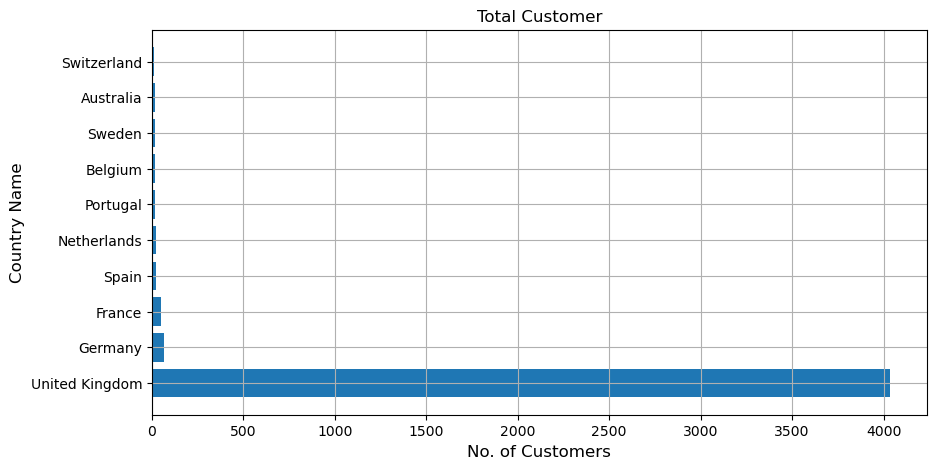

In [83]:
plt.figure(figsize=(10,5))
plt.barh(max_cus.index,max_cus.values)
plt.title("Total Customer",fontsize=12)
plt.xlabel("No. of Customers",fontsize=12)
plt.ylabel("Country Name",fontsize=12)
plt.grid(True)
plt.show()

Highest AOV

In [84]:
country_aov=(cr/max_orders).sort_values(ascending=False)
top10_aov = country_aov.head(10)
top10_aov

Country
Netherlands       1759.078400
Switzerland        866.868200
EIRE               785.249426
Sweden             619.952561
France             444.059863
Spain              435.907412
Portugal           416.851607
Germany            381.911152
Belgium            348.369692
United Kingdom     326.139074
dtype: float64

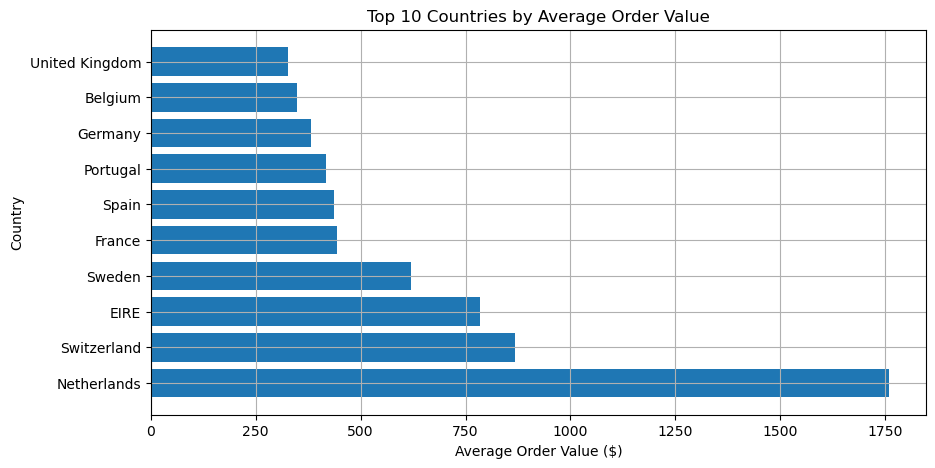

In [85]:
plt.figure(figsize=(10,5))

plt.barh(top10_aov.index, top10_aov.values)

plt.title("Top 10 Countries by Average Order Value")
plt.xlabel("Average Order Value ($)")
plt.ylabel("Country")

plt.grid(True)

plt.show()

### Observation

It means:

Customers in the Netherlands spend more money every time they place an order.

Whereas:

Customers in the UK place many more orders, but each order is smaller on average.

PRODUCT SOLD

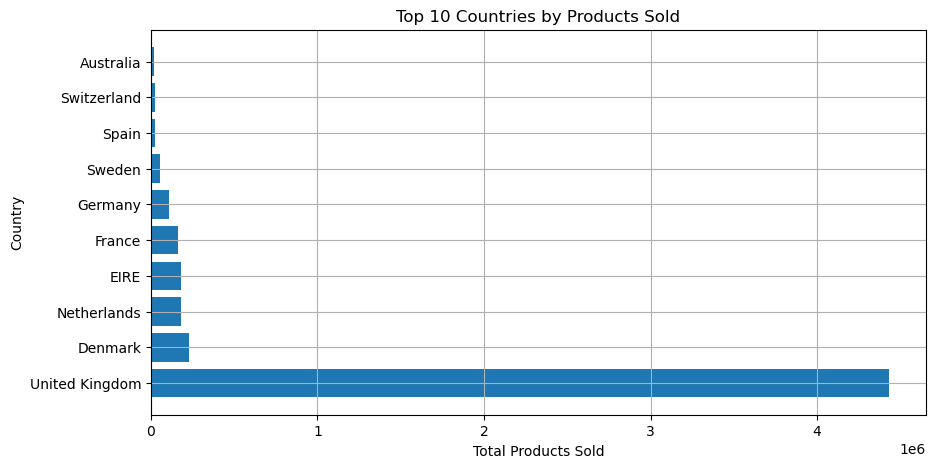

In [86]:
country_products=customer_df[customer_df["Quantity"] > 0].groupby("Country")["Quantity"].sum().sort_values(ascending=False)


top10_products = country_products.head(10)

plt.figure(figsize=(10,5))

plt.barh(top10_products.index, top10_products.values)

plt.title("Top 10 Countries by Products Sold")
plt.xlabel("Total Products Sold")
plt.ylabel("Country")

plt.grid(True)

plt.show()

### Conclusion

The analysis shows that the United Kingdom's revenue leadership is driven primarily by volume—more customers, more orders, and more products sold—rather than higher spending per transaction. In contrast, the Netherlands follows a value-driven purchasing pattern, where customers place fewer orders but spend significantly more on each order.

# PHASE 7 — Product Analysis

->PRODUCT ANALYSIS
    ->Business Questions

We are going to answer these questions:

* Which products generate the highest revenue?
* Which products are sold the most (Quantity)?
* Which products are ordered most frequently?
* Which products have the highest average selling price?
* Which products are returned the most?
* What business actions should the company take?

In [87]:
#  Which products contribute the most to total revenue?

In [88]:
sales_df=customer_df[customer_df["Quantity"]>0]
tot_rev=sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)

top_10_prod=tot_rev.head(10)

top_10_prod


Description
WHITE HANGING HEART T-LIGHT HOLDER     151339.16
REGENCY CAKESTAND 3 TIER               143727.60
Manual                                  98531.99
ASSORTED COLOUR BIRD ORNAMENT           70291.03
JUMBO BAG RED RETROSPOT                 51644.25
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40156.05
PAPER CHAIN KIT 50'S CHRISTMAS          36871.55
PARTY BUNTING                           35017.30
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

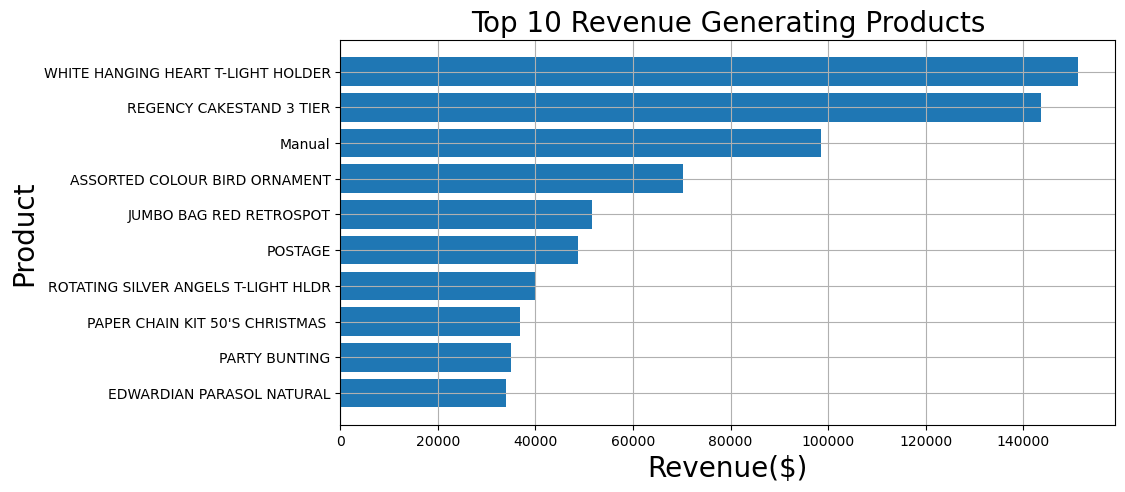

In [89]:
plt.figure(figsize=(10,5))
plt.barh(top_10_prod.index,top_10_prod.values)
plt.title("Top 10 Revenue Generating Products",fontsize=20)
plt.xlabel("Revenue($)",fontsize=20)

plt.ylabel("Product",fontsize=20)
plt.gca().invert_yaxis()  # zyda bik rahe prod ko uper print krwa diya 
plt.grid(True)
plt.show()


## Business Recommendation

The company should ensure adequate inventory for its highest revenue-generating products to avoid stock-outs during peak demand. Additionally, these products can be featured in promotional campaigns, bundled with complementary items, or recommended through cross-selling strategies to maximize revenue.

## follow up 
Why is WHITE HANGING HEART T-LIGHT HOLDER the highest revenue-generating product?

Possible reasons:

Is it sold in huge quantities?
Is it expensive?
Is it purchased by many customers?
Is it ordered very frequently?

We don't know yet.

In [90]:
# Top 10 Most Sold Products (by Quantity)

In [91]:
max_sold_prod=sales_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top10=max_sold_prod.head()
top10

Description
WHITE HANGING HEART T-LIGHT HOLDER    56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54610
BROCADE RING PURSE                    48166
PACK OF 72 RETRO SPOT CAKE CASES      45129
ASSORTED COLOUR BIRD ORNAMENT         44431
Name: Quantity, dtype: int64

# PHASE 8 — Customer Analysis (RFM)

Business Objective

The goal of this phase is to understand customer purchasing behaviour by analyzing how recently customers purchased, how frequently they purchase, and how much they spend. These insights will help identify valuable customers, inactive customers, and customers requiring retention strategies.

We are going to answer these questions:

* Who are our most valuable customers?
* Which customers purchase most frequently?
* Which customers spend the most money?
* Which customers have not purchased recently?
* How can we measure customer loyalty using RFM Analysis?

->what RFM is.

* Recency (R) : How recently has the customer made a purchase?
    * Business Meaning
         * Smaller Recency = Better customer
         * Larger Recency = Customer may churn
* Frequency (F): How often does the customer purchase?
    * Business Meaning
         * Higher Frequency = Loyal customer
         * Lower Frequency = Occasional customer
* Monetary (M) :How much money has the customer spent?
    * Business Meaning
        * Higher Monetary = High-value customer
        * Lower Monetary = Low-value customer

## RFM Table Creation

In [92]:
# rfm = customer_df.groupby("Customer ID").agg({"InvoiceDate": "max", "InvoiceNo.": "nunique","Revenue":"sum"})

# # Rename cols

# rfm.columns=["LastPurchased","Frequnecy","Monetary"]

# # calc recency
# # pd.Timedelta(days=1) => duration of exactly 1 day.
# snapshot_date=customer_df["InvoiceDate"].max()+pd.Timedelta(days=1)

# rfm["Recency"]=(snapshot_date - rfm["LastPurchased"]).dt.days

# # customer_df["InvoiceDate"].max(): This finds the latest 
# # date present in your entire dataset (the day the last transaction 
# # occurred). Let's pretend the last sale happened on December 10th.+ 
# # pd.Timedelta(days=1): This adds exactly one day to that maximum date 
# # (making it December 11th).The Reason: We do this to simulate "Today"
# # or a "Snapshot Date." If you don't add that 1 day, a customer who bought 
# # something on the very last day of the dataset would have a Recency score 
# # of 0 days, which can cause mathematical errors (like division by zero) 
# # later in your calculations.

# # rearrange cols
# rfm=rfm[["Recency","Frequnecy","Monetary"]]

# rfm.head()

# ==========================================
# RFM Table Creation
# ==========================================

rfm = customer_df.groupby("Customer ID").agg({
    "InvoiceDate": "max",      # Last Purchase Date
    "Invoice": "nunique",    # Number of Orders
    "Revenue": "sum"           # Total Customer Spend
})

# Rename Columns

rfm.columns = ["LastPurchaseDate", "Frequency", "Monetary"]

# Calculate Recency

snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm["Recency"] = (snapshot_date - rfm["LastPurchaseDate"]).dt.days

# Rearrange Columns

rfm = rfm[["Recency", "Frequency", "Monetary"]]

# Preview

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-51.74
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


Lekin ek cheez immediately notice hui:

CustomerID   Recency    Frequency    Monetary

12346         67         15          -51.74

⚠️ Negative Monetary?

Ye pehle verify karo.

Business ke perspective se Monetary = Total Spend hota hai. Agar kisi customer ka Monetary negative aa raha hai, to iska matlab:

returns/refunds include ho gaye hain, ya
tumne customer_df me cancelled invoices bhi rakh diye hain.

##### Structure
customer_df

   ↓
   
remove returns / cancelled transactions

   ↓
   
rfm_transactions

   ↓
   
RFM calculation

## Recency Analysis

In [93]:
rfm_transactions = customer_df[
    (customer_df["Customer ID"].notna()) &
    (customer_df["Quantity"] > 0) &
    (~customer_df["Invoice"].astype(str).str.startswith("C"))
].copy()

rfm_transactions.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,2009-12


In [94]:
rfm = rfm_transactions.groupby("Customer ID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
)

snapshot_date = rfm_transactions["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm["Recency"] = (
    snapshot_date - rfm["LastPurchaseDate"]
).dt.days

rfm = rfm[["Recency", "Frequency", "Monetary"]]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [95]:
rfm.describe()

,Recency,Frequency,Monetary
count,4314.000000,4314.000000,4314.000000
mean,91.269124,4.454103,2039.460766
std,96.943482,8.168658,8909.797773
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.105000
50%,53.000000,2.000000,700.405000
75%,136.000000,5.000000,1713.297500
max,374.000000,205.000000,349164.350000


#### Business interpretation: customer activity is not evenly distributed; there is a meaningful group of customers who have not purchased for several months.

### Business Question

How recently are our customers purchasing from the business?

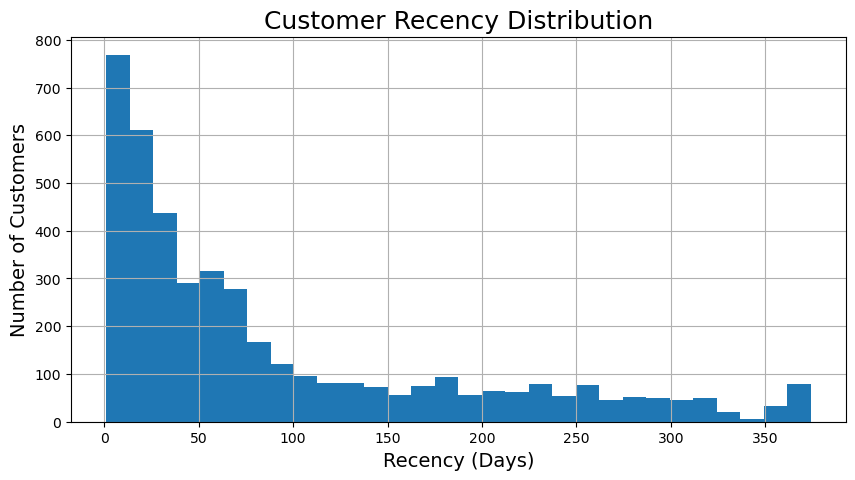

In [96]:
plt.figure(figsize=(10, 5))

plt.hist(rfm["Recency"], bins=30)

plt.title("Customer Recency Distribution", fontsize=18)
plt.xlabel("Recency (Days)", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.grid(True)
plt.show()

### Graph says:
* The graph is "right-skewed" (or positively skewed) distribution, meaning the data is not balanced.The absolute highest peak of the data sits on the left side (low values).
* this is a Recency chart (measuring Days since the last purchase),The vast majority of your customers bought something very recently (less than 2 months ago). This proves the e-commerce store has a highly active, healthy, and engaged customer

## Frequency Analysis

Q.Business question:

How frequently do customers place orders?

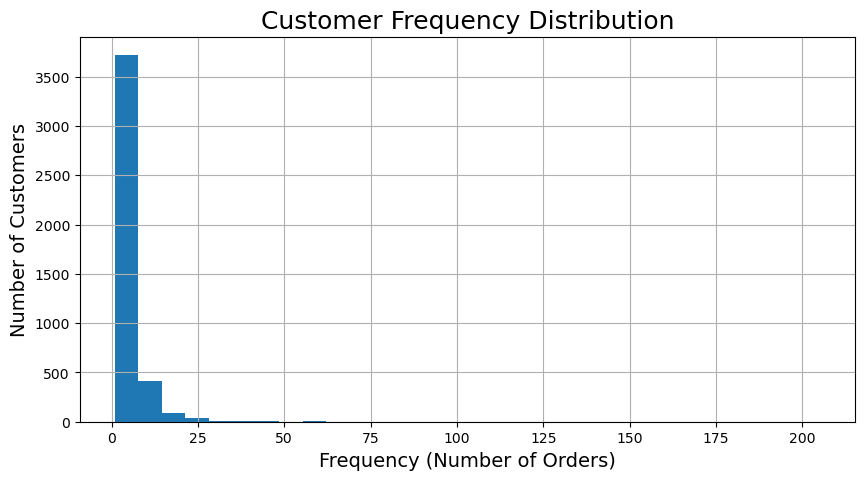

In [97]:
plt.figure(figsize=(10, 5))

plt.hist(rfm["Frequency"], bins=30)

plt.title("Customer Frequency Distribution", fontsize=18)
plt.xlabel("Frequency (Number of Orders)", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.grid(True)
plt.show()

### Observation

The Frequency distribution is highly right-skewed. The majority of customers have placed only a small number of orders, with the largest concentration occurring at low purchase frequencies. As order frequency increases, the number of customers decreases sharply. A small group of customers shows exceptionally high purchase frequency, with some customers placing more than 100 orders.

## Monetary Analysis

Business Question:

How much do our customers spend?

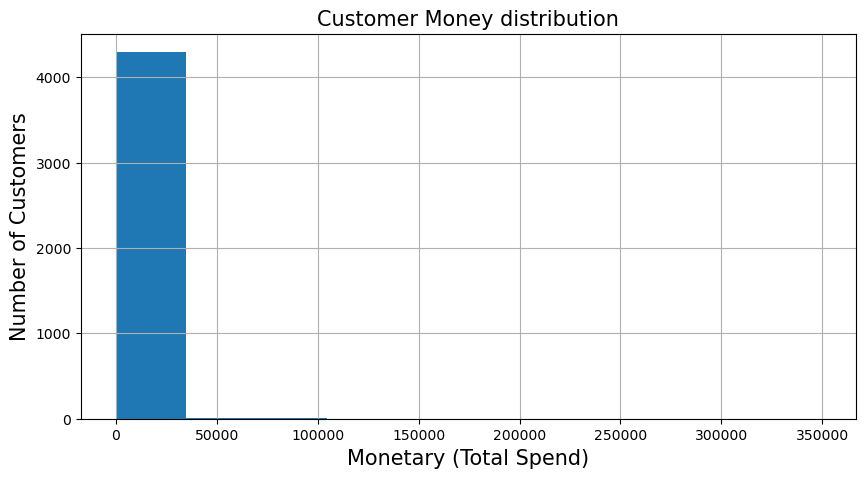

In [98]:
plt.figure(figsize=(10,5))

plt.hist(rfm["Monetary"])

plt.title("Customer Money distribution",fontsize=15)
plt.xlabel("Monetary (Total Spend)",fontsize=15)
plt.ylabel("Number of Customers",fontsize=15)
plt.grid(True)
plt.show()

### Observation

The Monetary distribution is highly right-skewed. The majority of customers have relatively low total spending

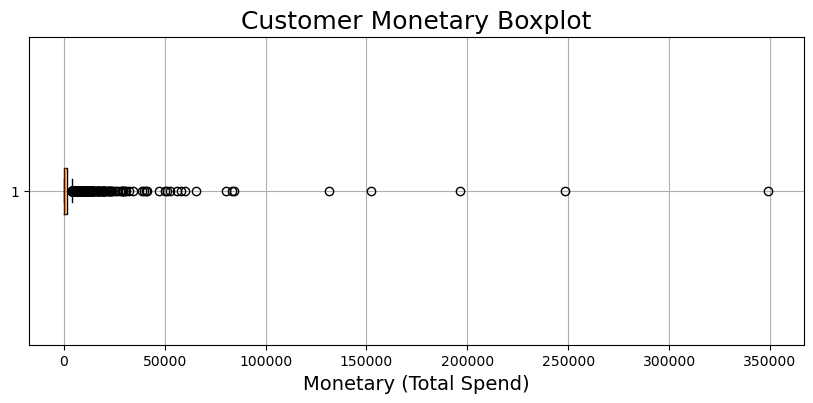

In [99]:
# Monetary Boxplot

plt.figure(figsize=(10, 4))

plt.boxplot(rfm["Monetary"], vert=False)

plt.title("Customer Monetary Boxplot", fontsize=18)
plt.xlabel("Monetary (Total Spend)", fontsize=14)

plt.grid(True)
plt.show()

## RFM Correlation Analysis

In [100]:
# 1. Calculate correlation

rfm_corr=rfm[["Recency","Frequency","Monetary"]].corr()

rfm_corr

,Recency,Frequency,Monetary
Recency,1.000000,-0.248928,-0.120860
Frequency,-0.248928,1.000000,0.655513
Monetary,-0.120860,0.655513,1.000000


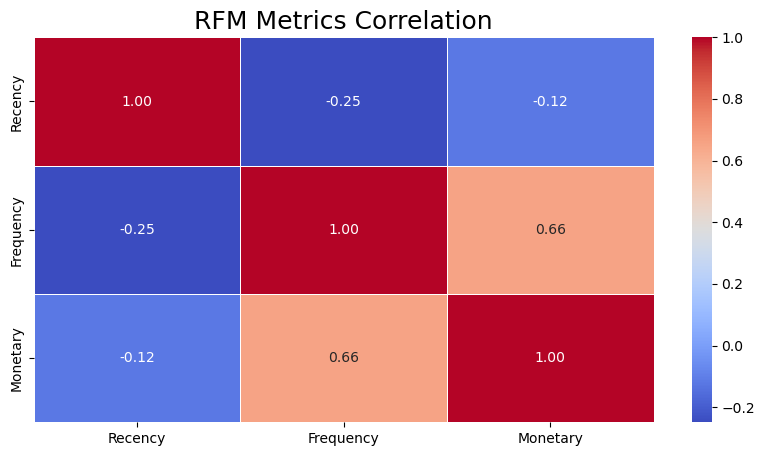

In [101]:
# 2. Create the heatmap
import seaborn as sns
plt.figure(figsize=(10,5))

sns.heatmap(rfm_corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)

plt.title("RFM Metrics Correlation", fontsize=18)
plt.show()

## Identify Top Customers

Look at:

* Top customers by Monetary
* Top customers by Frequency
* Most recent customers by Recency

In [102]:
# 1. Top 10 customers by Monetary

top_money=rfm.sort_values(by="Monetary",ascending=False).head(10)
top_money

,Recency,Frequency,Monetary
Customer ID,,,
18102.0,1,89,349164.35
14646.0,10,78,248396.50
14156.0,7,102,196549.74
14911.0,1,205,152121.22
13694.0,9,94,131443.19
17511.0,3,31,84541.17
15061.0,3,86,83284.38
16684.0,15,27,80489.21
16754.0,8,29,65500.07


In [103]:
# 2. Top 10 customers by Frequency

top_freq=rfm.sort_values(by="Frequency",ascending=False).head(10)
top_freq

,Recency,Frequency,Monetary
Customer ID,,,
14911.0,1,205,152121.22
17850.0,8,155,51208.87
12748.0,1,144,22457.90
15311.0,1,121,55942.74
13089.0,4,109,57885.45
14156.0,7,102,196549.74
14606.0,2,102,18482.10
13694.0,9,94,131443.19
17841.0,1,91,29562.02


In [104]:
# 3. Most Recent 10 Customers

top_rec=rfm.sort_values(by="Recency",ascending=True).head(10)
top_rec

,Recency,Frequency,Monetary
Customer ID,,,
17430.0,1,3,469.41
15271.0,1,10,2146.95
13102.0,1,14,5272.83
13090.0,1,13,5189.32
15211.0,1,1,383.07
15192.0,1,3,937.07
16255.0,1,8,2284.34
17950.0,1,6,947.26
15079.0,1,8,2871.74


# Phase 9: Customer Segmentation


* Simple idea
    * Phase 8 mein humne customer ko samjha:
       * Recent hai ya purana?
       * Kitni baar order karta hai?
       * Kitna paisa spend karta hai?

    * Ab Phase 9 mein hum in teen cheezon ke basis par customers ko groups mein divide karenge.
    * For example:
         * Customer A → very good customer
         *  Customer B → normal customer
         * Customer C → risk mein hai

Isko RFM Segmentation bolenge.

----------------------------------------
-----------------------------------------------------
# STEP 1 — RFM Scores banana
    * Tumhare paas abhi ye hai:

        Customer	Recency	Frequency	Monetary
        12347	3	2	1323
        12348	74	1	222
        12349	43	3	2671

     * Ab har column ko 1 se 5 ka score dena hai.

* Recency: Yahan ulta scoring hoga:
    * Recent customer = good = 5
    * Bahut purana customer = bad = 1
    * Example: Recency	Score
                Veryrecent	5
                Recent	4
                Medium	3
                    Old	2
                Very old  1
* Frequency Yahan simple hai:
    * More orders = better score

        Frequency	Score
        Very high	5
        High	4
        Medium	3
        Low	2
        Very low	1
        Monetary

* Same:More spending = better score

        Monetary	Score
        Very high	5
        High	4
        Medium	3
        Low	2
        Very low	1
        Hum scores manually nahi denge

* Tumhare paas 4,314 customers hain, so manually ranges decide karna stupid hoga 😭.

* Hum quantiles use karenge.

* Basically Python customers ko 5 roughly equal groups mein divide karega:

* 20% customers → Score 1
* 20% customers → Score 2
* 20% customers → Score 3
* 20% customers → Score 4
* 20% customers → Score 5

* Recency mein direction reverse karenge, kyunki low Recency = good.


In [111]:
# RFM Scoring 

rfm["R_score"]=pd.qcut(rfm["Recency"],q=5,labels=[5,4,3,2,1])
rfm["F_score"]=pd.cut(rfm["Frequency"],bins=[0, 1, 2, 5, 10,float("inf")],labels=[1,2,3,4,5])
rfm["M_score"]=pd.qcut(rfm["Monetary"],q=5,labels=[1,2,3,4,5])
rfm.head()

,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score
Customer ID,,,,,,,
12346.0,165,11,372.86,5,2,252,2
12347.0,3,2,1323.32,2,4,524,5
12348.0,74,1,222.16,1,1,211,2
12349.0,43,3,2671.14,3,5,335,3
12351.0,11,1,300.93,1,2,512,5


* qcut() → data ko roughly equal number of customers ke groups mein divide karta hai.

* cut() → hum khud meaningful ranges define karte hain.

Tumhare Frequency distribution mein qcut() problematic tha, isliye pd.cut() better choice thi.

In [112]:
# rfm.drop(columns=["R_score"], inplace=True)
# rfm.head()

Humne har customer ko 3 scores de diye:

* R_score → customer kitna recently purchase karta hai
* F_score → kitni frequently purchase karta hai
* M_score → kitna spend karta hai

Ab next step hai in teen scores ko ek combined RFM score mein convert karna.

Example:

R = 5 , F = 4 , M = 5

RFM = 545

Phir isi score ke basis par hum customers ko:

Champions / Loyal Customers / At Risk / Hibernating / etc.

## STEP -2 Combined RFM Score

In [113]:
rfm["RFM_Score"] = rfm["R_score"].astype(str)+rfm["F_score"].astype(str)+rfm["M_score"].astype(str)
rfm.head()


,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score
Customer ID,,,,,,,
12346.0,165,11,372.86,5,2,252,2
12347.0,3,2,1323.32,2,4,524,5
12348.0,74,1,222.16,1,1,211,2
12349.0,43,3,2671.14,3,5,335,3
12351.0,11,1,300.93,1,2,512,5


Iska meaning

12347 → 524

* 5 → very recent ✅
* 2 → low frequency
* 4 → high monetary value

So ye customer recent + high spending, but not particularly frequent.

In [114]:
rfm["RFM_Total"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)
rfm.head()
# Ab maximum possible:

# 5 + 5 + 5 = 15

# Minimum:

# 1 + 1 + 1 = 3

# So:

# Higher RFM_Total = generally better customer

,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total
Customer ID,,,,,,,,
12346.0,165,11,372.86,5,2,252,2,9
12347.0,3,2,1323.32,2,4,524,5,11
12348.0,74,1,222.16,1,1,211,2,4
12349.0,43,3,2671.14,3,5,335,3,11
12351.0,11,1,300.93,1,2,512,5,8


## Step 3: Customer Segments

| Customer type           | Meaning                                        |
| ----------------------- | ---------------------------------------------- |
| **Champions**           | Recent + frequent + high spending              |
| **Loyal Customers**     | Frequently purchase karte hain                 |
| **Potential Loyalists** | Recently aaye hain, potential hai              |
| **At Risk**             | Pehle valuable the, ab inactive ho rahe hain   |
| **Hibernating**         | Long time se purchase nahi kiya + low activity |


In [115]:
rfm["RFM_Total"].value_counts().sort_index()

RFM_Total
3     340
4     369
5     345
6     379
7     418
8     377
9     371
10    402
11    346
12    284
13    234
14    233
15    216
Name: count, dtype: int64

In [116]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
111    340
112    183
113     47
114     16
115      6
      ... 
543     12
544     91
545    150
554     12
555    216
Name: count, Length: 106, dtype: int64

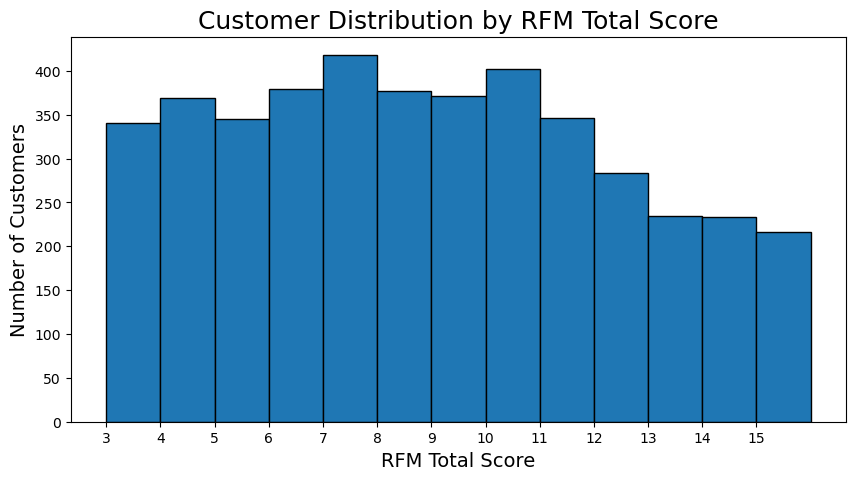

In [117]:
plt.figure(figsize=(10, 5))

plt.hist(
    rfm["RFM_Total"],
    bins=range(3, 17),
    edgecolor="black"
)

plt.title("Customer Distribution by RFM Total Score", fontsize=18)
plt.xlabel("RFM Total Score", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.xticks(range(3, 16))
# plt.grid(True)

plt.show()

In [118]:
def segment_customer(row):

    R = int(row["R_score"])
    F = int(row["F_score"])
    M = int(row["M_score"])

    # 1. Champions
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    # 2. Loyal Customers
    elif F >= 4 and M >= 3:
        return "Loyal Customers"

    # 3. Potential Loyalists
    elif R >= 4 and F <= 3:
        return "Potential Loyalists"

    # 4. At Risk
    elif R <= 2 and (F >= 3 or M >= 3):
        return "At Risk"

    # 5. Hibernating
    elif R <= 2 and F <= 2 and M <= 2:
        return "Hibernating"

    # 6. Remaining customers
    else:
        return "Others"

In [119]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [120]:
rfm["Segment"].value_counts()
# Kitne customers kis segment mein hain?

Segment
Potential Loyalists    1036
Hibernating             947
Others                  731
Champions               699
At Risk                 668
Loyal Customers         233
Name: count, dtype: int64

In [121]:
# Percentage
rfm["Segment"].value_counts(normalize=True).mul(100).round(2)

Segment
Potential Loyalists    24.01
Hibernating            21.95
Others                 16.94
Champions              16.20
At Risk                15.48
Loyal Customers         5.40
Name: proportion, dtype: float64

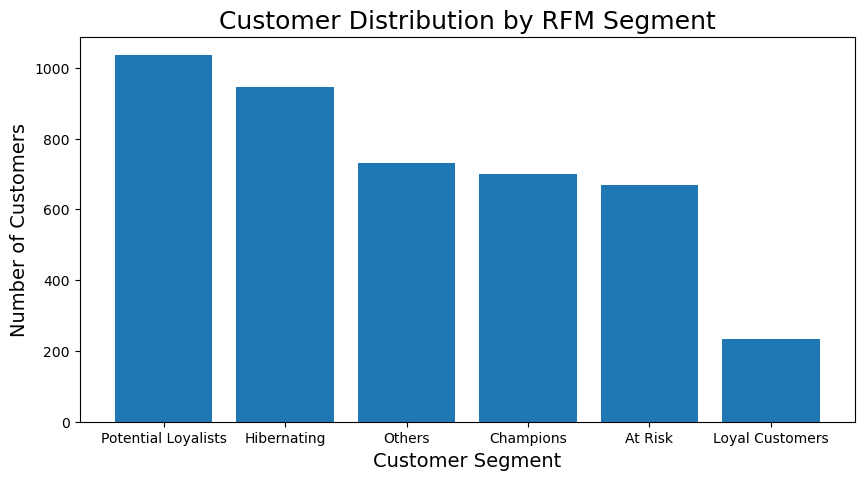

In [122]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 5))

plt.bar(segment_counts.index, segment_counts.values)

plt.title("Customer Distribution by RFM Segment", fontsize=18)
plt.xlabel("Customer Segment", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

# plt.xticks(rotation=30)
# plt.grid(True)

plt.show()

In [123]:
rfm.head()

,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment
Customer ID,,,,,,,,,
12346.0,165,11,372.86,5,2,252,2,9,At Risk
12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists
12348.0,74,1,222.16,1,1,211,2,4,Hibernating
12349.0,43,3,2671.14,3,5,335,3,11,Others
12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists


In [124]:
# Har segment actually kitna revenue generate karta hai?

segment_revenue = (rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False))

segment_revenue

Segment
Champions              5278728.187
Potential Loyalists     964129.841
At Risk                 880693.704
Loyal Customers         805863.221
Others                  649709.590
Hibernating             219109.201
Name: Monetary, dtype: float64

In [125]:
# Revenue percentage bhi nikalo:
segment_revenue_percent = (segment_revenue / segment_revenue.sum() * 100).round(2)

segment_revenue_percent

Segment
Champions              60.00
Potential Loyalists    10.96
At Risk                10.01
Loyal Customers         9.16
Others                  7.38
Hibernating             2.49
Name: Monetary, dtype: float64

In [126]:
segment_analysis = pd.DataFrame({
    "Total Revenue": segment_revenue,
    "Revenue %": segment_revenue_percent
})

segment_analysis

,Total Revenue,Revenue %
Segment,,
Champions,5278728.187,60.00
Potential Loyalists,964129.841,10.96
At Risk,880693.704,10.01
Loyal Customers,805863.221,9.16
Others,649709.590,7.38
Hibernating,219109.201,2.49


* Champions sirf 16.2% customers hain, but they generate 60% of total revenue.
* Hibernating customers 21.95% of customers hain, but contribute only 2.49% revenue. So inko blindly discounts dena necessarily profitable nahi hoga.
* At Risk: 15.48% customers → 10.01% revenue
    * Ye segment interesting hai because in customers mein past purchasing value hai, but they're becoming inactive.Inko retain/win-back karna commercially meaningful ho sakta hai.

In [127]:
segment_avg = (rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False))

segment_avg

Segment
Champions              7551.828594
Loyal Customers        3458.640433
At Risk                1318.403749
Potential Loyalists     930.627260
Others                  888.795609
Hibernating             231.371912
Name: Monetary, dtype: float64

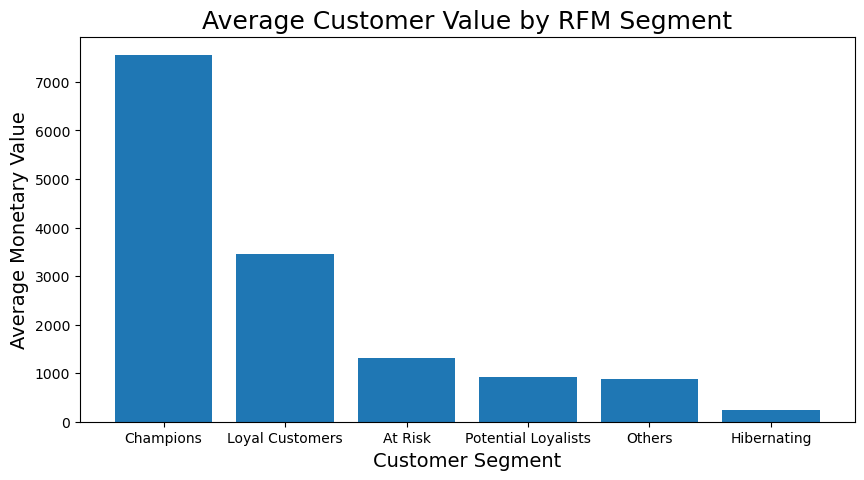

In [128]:
plt.figure(figsize=(10,5))

plt.bar(segment_avg.index, segment_avg.values)

plt.title("Average Customer Value by RFM Segment", fontsize=18)
plt.xlabel("Customer Segment", fontsize=14)
plt.ylabel("Average Monetary Value", fontsize=14)

# plt.xticks(rotation=30)


plt.show()

What the graph tells us:
* Champions: average value is by far the highest (~7.5k). Combined with the earlier finding that they generate 60% of revenue, these customers are the most important group to retain.

* Loyal Customers: second-highest average value (~3.5k), so they are also valuable even though their customer count is smaller.

* At Risk: average value is around ~1.3k. This is an important win-back opportunity because these customers have meaningful historical value.

* Potential Loyalists: average value is under ~1k. Their main opportunity is converting them into repeat/loyal customers.

* Hibernating: lowest average value (~250), consistent with their very low 2.49% revenue contribution.

# Final RFM Segment Summary

In [129]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Total_Revenue=("Monetary", "sum"),
    Average_Customer_Value=("Monetary", "mean")
)

# Customer percentage
segment_summary["Customer_%"] = (
    segment_summary["Customers"] / len(rfm) * 100
).round(2)

# Revenue percentage
segment_summary["Revenue_%"] = (
    segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
).round(2)

# Arrange columns
segment_summary = segment_summary[
    [
        "Customers",
        "Customer_%",
        "Total_Revenue",
        "Revenue_%",
        "Average_Customer_Value"
    ]
]

# Sort by revenue contribution
segment_summary = segment_summary.sort_values(
    "Revenue_%",
    ascending=False
)

segment_summary

,Customers,Customer_%,Total_Revenue,Revenue_%,Average_Customer_Value
Segment,,,,,
Champions,699,16.20,5278728.187,60.00,7551.828594
Potential Loyalists,1036,24.01,964129.841,10.96,930.627260
At Risk,668,15.48,880693.704,10.01,1318.403749
Loyal Customers,233,5.40,805863.221,9.16,3458.640433
Others,731,16.94,649709.590,7.38,888.795609
Hibernating,947,21.95,219109.201,2.49,231.371912


# PHASE 10 — Cohort Analysis + Historical CLV(Customer Lifetime Value)

->Is phase mein 2 main cheezein karenge:

* Part A — Cohort Analysis
    * Already SQL mein cohort analysis kiya hai, but ab Python mein proper retention table + heatmap banayenge.
    * Cohort analysis is a way of studying how different groups of people behave over time.Instead of looking at all your customers as one big crowd, you split them into smaller groups (called cohorts) that share something in common

* Part B — Historical CLV
    * Har customer ne ab tak company ko kitna revenue diya → uska analysis.

In [130]:
cohort_df=df.copy()

In [131]:
# Customer ne pehli baar kis month mein purchase kiya?
cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])

cohort_df["CohortMonth"] = (
cohort_df.groupby("Customer ID")["InvoiceDate"]
    .transform("min")
    .dt.to_period("M")
)

In [132]:
cohort_df[["Customer ID", "InvoiceDate", "CohortMonth"]].head()

,Customer ID,InvoiceDate,CohortMonth
0,13085.0,2009-12-01 07:45:00,2009-12
1,13085.0,2009-12-01 07:45:00,2009-12
2,13085.0,2009-12-01 07:45:00,2009-12
3,13085.0,2009-12-01 07:45:00,2009-12
4,13085.0,2009-12-01 07:45:00,2009-12


### Cohort Index

Ab hume pata hai customer kis month mein first time aaya.

Ab calculate karenge:

First purchase ke baad customer kitne months tak active raha?

->Cohort Analysis ka goal hai dekhna:

Jo customers kisi particular month mein first time aaye, unmein se kitne customers baad ke months mein wapas aaye?

Iske liye hume 2 cheezein chahiye:

Customer kab first time aaya → CohortMonth
Customer kis month mein purchase kar raha hai → PurchaseMonth

In [133]:
cohort_df["PurchaseMonth"] = cohort_df["InvoiceDate"].dt.to_period("M")

cohort_df["CohortIndex"] = (
    (cohort_df["PurchaseMonth"].dt.year - cohort_df["CohortMonth"].dt.year) * 12
    +
    (cohort_df["PurchaseMonth"].dt.month - cohort_df["CohortMonth"].dt.month)
    + 1
)

cohort_df[["Customer ID", "CohortMonth", "PurchaseMonth", "CohortIndex"]].head(10)


,Customer ID,CohortMonth,PurchaseMonth,CohortIndex
0,13085.0,2009-12,2009-12,1
1,13085.0,2009-12,2009-12,1
2,13085.0,2009-12,2009-12,1
3,13085.0,2009-12,2009-12,1
4,13085.0,2009-12,2009-12,1
5,13085.0,2009-12,2009-12,1
6,13085.0,2009-12,2009-12,1
7,13085.0,2009-12,2009-12,1
8,13085.0,2009-12,2009-12,1
9,13085.0,2009-12,2009-12,1


In [134]:
cohort_counts = (cohort_df .groupby(["CohortMonth", "CohortIndex"])["Customer ID"] .nunique()
                 .reset_index())

cohort_counts.head(10)


,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,1045
1,2009-12,2,392
2,2009-12,3,358
3,2009-12,4,447
4,2009-12,5,410
5,2009-12,6,408
6,2009-12,7,408
7,2009-12,8,374
8,2009-12,9,355
9,2009-12,10,392


In [135]:
# Retention Matrix
retention_matrix = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer ID"
)

retention_matrix

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,1045.0,392.0,358.0,447.0,410.0,408.0,408.0,374.0,355.0,392.0,452.0,518.0,260.0
2010-01,394.0,86.0,119.0,120.0,110.0,115.0,105.0,91.0,114.0,134.0,122.0,37.0,NaN
2010-02,363.0,109.0,82.0,110.0,93.0,76.0,79.0,103.0,100.0,106.0,32.0,NaN,NaN
2010-03,436.0,95.0,113.0,103.0,100.0,87.0,105.0,130.0,126.0,36.0,NaN,NaN,NaN
2010-04,291.0,67.0,58.0,47.0,54.0,67.0,79.0,76.0,22.0,NaN,NaN,NaN,NaN
2010-05,254.0,49.0,45.0,49.0,48.0,66.0,56.0,22.0,NaN,NaN,NaN,NaN,NaN
2010-06,269.0,58.0,53.0,55.0,62.0,76.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,183.0,38.0,37.0,52.0,55.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,158.0,39.0,50.0,51.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Meaning:

* Row = customers ka first purchase month
* Column 1 = first month
* Column 2 = first month ke 1 month baad
* Column 3 = first month ke 2 months baad
* Values = kitne unique customers wapas aay

In [136]:
# Retention %
# Retention % = Current Month Customers ÷ Month 1 Customers × 100

retention_percent = retention_matrix.div(
    retention_matrix[1],
    axis=0
) * 100

retention_percent = retention_percent.round(2)

retention_percent


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,37.51,34.26,42.78,39.23,39.04,39.04,35.79,33.97,37.51,43.25,49.57,24.88
2010-01,100.0,21.83,30.20,30.46,27.92,29.19,26.65,23.10,28.93,34.01,30.96,9.39,NaN
2010-02,100.0,30.03,22.59,30.30,25.62,20.94,21.76,28.37,27.55,29.20,8.82,NaN,NaN
2010-03,100.0,21.79,25.92,23.62,22.94,19.95,24.08,29.82,28.90,8.26,NaN,NaN,NaN
2010-04,100.0,23.02,19.93,16.15,18.56,23.02,27.15,26.12,7.56,NaN,NaN,NaN,NaN
2010-05,100.0,19.29,17.72,19.29,18.90,25.98,22.05,8.66,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,21.56,19.70,20.45,23.05,28.25,7.43,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,20.77,20.22,28.42,30.05,11.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,24.68,31.65,32.28,12.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Business Observation
First month mein 100% customers obviously cohort mein present hain. Second month mein sirf 35% return hue, aur third month mein 25% remain active rahe.

Isse customer retention/drop-off clearly dikhta hai.

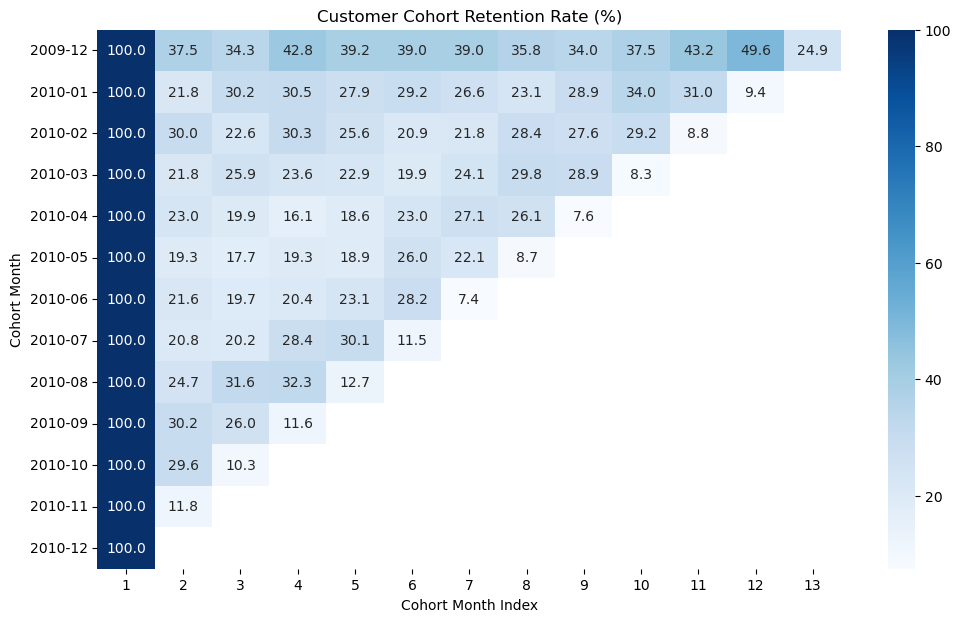

In [137]:
# Retention Heatmap

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_percent,
    annot=True,   #Har cell ke andar actual percentage number bhi show karega.
    fmt=".1f",    #Numbers ko 1 decimal place tak show karega.
    cmap="Blues"
)

plt.title("Customer Cohort Retention Rate (%)")
plt.xlabel("Cohort Month Index")
plt.ylabel("Cohort Month")
plt.show()

## 💼 Business Observations

1. Initial drop-off kaafi strong hai.
Most cohorts mein Month 2 retention roughly 19–30% hai. Matlab first purchase ke baad large number of customers immediately return nahi karte.

2. Kuch cohorts relatively stronger hain.
For example, 2009-12 cohort Month 2 mein 37.5% retain karta hai aur later months mein bhi comparatively strong retention dikhata hai. Month 12 tak bhi 49.6% shown hai, although later-month cohort sizes should be interpreted carefully.

3. Recent cohorts ko directly older cohorts se compare nahi karna chahiye.
2010-10, 2010-11, 2010-12 jaise newer cohorts ke paas fewer months of history hai, isliye unke later columns naturally missing hain.

🎯 Business Action

Company ko first purchase ke immediately baad retention improve karne par focus karna chahiye — e.g. follow-up offers, personalized recommendations, reminders, and second-purchase incentives

### Historical CLV
Har customer ne historically total kitna spend kiya?

In [138]:
clv_df = (
    cohort_df[cohort_df["Quantity"] > 0]
    .groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index(name="Historical_CLV")
)

clv_df.head()

,Customer ID,Historical_CLV
0,12346.0,372.86
1,12347.0,1323.32
2,12348.0,222.16
3,12349.0,2671.14
4,12351.0,300.93


In [139]:
top_clv_customers = (
    clv_df
    .sort_values("Historical_CLV", ascending=False)
    .head(10)
)

top_clv_customers

,Customer ID,Historical_CLV
4185,18102.0,349164.35
1638,14646.0,248396.50
1270,14156.0,196566.74
1842,14911.0,152147.57
939,13694.0,131443.19
3746,17511.0,84541.17
1953,15061.0,83284.38
3130,16684.0,80489.21
3179,16754.0,65500.07
4067,17949.0,60117.60


## CLV Distribution

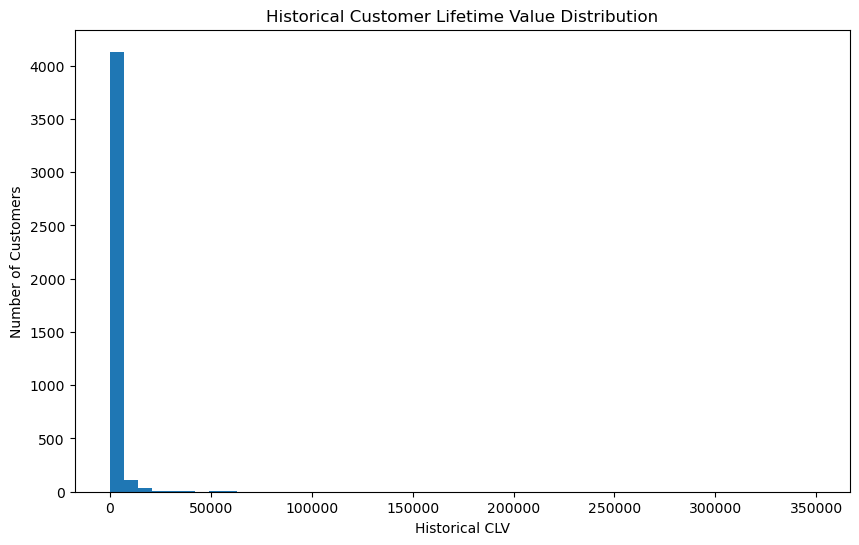

In [140]:
plt.figure(figsize=(10, 6))

plt.hist(clv_df["Historical_CLV"], bins=50)

plt.title("Historical Customer Lifetime Value Distribution")
plt.xlabel("Historical CLV")
plt.ylabel("Number of Customers")


plt.show()

# PHASE 11 — Feature Engineering

Ab hum Machine Learning ke liye customer data ready karenge.

Simple language mein:

Raw data ko aise useful features mein convert karna jo model ko customer behaviour samajhne mein help karein.

## Step 1 — Customer-level dataset banao

Hum RFM + CLV ko ek table mein combine karenge

In [145]:
ml_df = rfm.copy()

ml_df = ml_df.reset_index()

ml_df = ml_df.merge(
    clv_df,
    on="Customer ID",
    how="left"
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93


## Step 2: Average Order Value (AOV)
AOV = customer ka average spend per order

In [146]:
ml_df["AOV"] = ml_df["Monetary"] / ml_df["Frequency"]

ml_df[["Customer ID", "Monetary", "Frequency", "AOV"]].head()

,Customer ID,Monetary,Frequency,AOV
0,12346.0,372.86,11,33.896364
1,12347.0,1323.32,2,661.660000
2,12348.0,222.16,1,222.160000
3,12349.0,2671.14,3,890.380000
4,12351.0,300.93,1,300.930000


### Business observation

High AOV → customer per order zyada spend karta hai.

Low AOV → customer frequently purchase kar sakta hai but small-value orders karta hai.

## Step 3: Average Basket Size

Ab ek aur useful customer feature banate hain:

Customer average order mein kitne items purchase karta hai?

In [144]:
# Step 3 — Customer's Total Purchase Quantity

quantity_df = (
    cohort_df[cohort_df["Quantity"] > 0]
    .groupby("Customer ID")["Quantity"]
    .sum()
    .reset_index(name="Total_Quantity")
)

ml_df = ml_df.merge(
    quantity_df,
    on="Customer ID",
    how="left"
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV,Avg_Items_Per_Order,Total_Quantity_x,Total_Quantity_y
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364,33.896364,70,70
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000,661.660000,828,828
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000,222.160000,373,373
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000,890.380000,993,993
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000,300.930000,261,261


In [150]:
ml_df = ml_df.drop(
    columns=["Total_Quantity_y"],
    errors="ignore"
)

ml_df = ml_df.rename(
    columns={"Total_Quantity_x": "Total_Quantity"}
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000


###  Step 4: Total Quantity
Abhi Frequency batata hai kitne orders kiye, but hume ye bhi pata hona chahiye ki customer ne total kitne items kharide.

In [151]:
quantity_df = (
    cohort_df[cohort_df["Quantity"] > 0]
    .groupby("Customer ID")["Quantity"]
    .sum()
    .reset_index(name="Total_Quantity")
)

ml_df = ml_df.merge(
    quantity_df,
    on="Customer ID",
    how="left"
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV,Total_Quantity
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364,70
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000,828
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000,373
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000,993
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000,261


### Business observation
High Total_Quantity → customer high-volume buyer ho sakta hai.
Low Total_Quantity + high Frequency → customer small quantities mein frequently buy karta hai.
Is feature se customer behaviour ko RFM se thoda aur deeply understand kar sakte hain.

### Step 5: Unique Products Purchased
Ab hum dekhenge:

Customer ne kitne different products purchase kiye?

Customer ne 500 items purchase kiye, but agar woh sirf 5 different products the, toh behaviour different hai compared to someone buying 500 items across 100 products.


Why?

Ye customer ki product diversity batata hai.

💼 Business meaning
High Unique_Products → customer ka product range broad hai.
Low Unique_Products → customer limited products kharidta hai.

In [152]:
product_df = (
    cohort_df[cohort_df["Quantity"] > 0]
    .groupby("Customer ID")["StockCode"]
    .nunique()
    .reset_index(name="Unique_Products")
)

ml_df = ml_df.merge(
    product_df,
    on="Customer ID",
    how="left"
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV,Total_Quantity,Unique_Products
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364,70,26
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000,828,70
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000,373,20
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000,993,90
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000,261,21


### Step 6: Customer Purchase Frequency

Ek aur useful feature banate hain:

Customer average mein kitne din ke gap par purchase karta hai?

In [154]:
purchase_span = (
    cohort_df[cohort_df["Quantity"] > 0]
    .groupby("Customer ID")["InvoiceDate"]
    .agg(["min", "max"])
    .reset_index()
)

purchase_span["Purchase_Span_Days"] = (
    purchase_span["max"] - purchase_span["min"]
).dt.days

ml_df = ml_df.merge(
    purchase_span[["Customer ID", "Purchase_Span_Days"]],
    on="Customer ID",
    how="left"
)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV,Total_Quantity,Unique_Products,Purchase_Span_Days
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364,70,26,196
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000,828,70,37
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000,373,20,0
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000,993,90,181
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000,261,21,0


## Step 7 — Average Days Between Purchases

In [155]:
ml_df["Avg_Days_Between_Purchases"] = (
    ml_df["Purchase_Span_Days"] / (ml_df["Frequency"] - 1)
).replace([float("inf"), -float("inf")], 0).fillna(0)

ml_df.head()

,Customer ID,Recency,Frequency,Monetary,F_score,M_score,RFM_Score,R_score,RFM_Total,Segment,Historical_CLV,AOV,Total_Quantity,Unique_Products,Purchase_Span_Days,Avg_Days_Between_Purchases
0,12346.0,165,11,372.86,5,2,252,2,9,At Risk,372.86,33.896364,70,26,196,19.6
1,12347.0,3,2,1323.32,2,4,524,5,11,Potential Loyalists,1323.32,661.660000,828,70,37,37.0
2,12348.0,74,1,222.16,1,1,211,2,4,Hibernating,222.16,222.160000,373,20,0,0.0
3,12349.0,43,3,2671.14,3,5,335,3,11,Others,2671.14,890.380000,993,90,181,90.5
4,12351.0,11,1,300.93,1,2,512,5,8,Potential Loyalists,300.93,300.930000,261,21,0,0.0


#  Phase 12 — Churn Prediction / ML
Ab hum predict karenge:

Kaunsa customer churn karne ke risk mein hai?

## Step 1 — Churn Target banana

Sabse pehle ML ko batana padega ki churned customer kaun hai.

Hum simple rule use karenge:

Recency > 90 days → Churn = 1

Recency ≤ 90 days → Churn = 0


* Churn = 1 → Customer churned / inactive hai.
    Yaani usne 90+ days se purchase nahi kiya.
* Churn = 0 → Customer active hai.
    Yaani usne last 90 days ke andar purchase kiya

In [156]:
ml_df["Churn"] = (ml_df["Recency"] > 90).astype(int)

ml_df[["Customer ID", "Recency", "Churn"]].head(10)

,Customer ID,Recency,Churn
0,12346.0,165,1
1,12347.0,3,0
2,12348.0,74,0
3,12349.0,43,0
4,12351.0,11,0
5,12352.0,11,0
6,12353.0,44,0
7,12355.0,203,1
8,12356.0,16,0
9,12357.0,24,0


## Step 2 — Churn distribution

In [157]:
ml_df["Churn"].value_counts()

Churn
0    2877
1    1437
Name: count, dtype: int64

Business observation

Active customers  = 2877 → 66.7%

Churn customers   = 1437 → 33.3%

## Step 3 — Features (X) aur Target (y
Ab model ko do cheezein deni hain:

X → customer ki information

y → answer, yani Churn

In [158]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AOV",
    "Total_Quantity",
    "Unique_Products",
    "Purchase_Span_Days",
    "Avg_Days_Between_Purchases",
    "RFM_Total",
    "Historical_CLV"
]

X = ml_df[features]
y = ml_df["Churn"]

###  Step 4: Train-Test Split

* Ab data ko 2 parts mein divide karenge:
    * Training data (80%) → model isse seekhega
    * Testing data (20%) → model ko check karenge ki usne kitna sahi seekha

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# stratify=y: Ye important hai. Training aur testing dono mein Churn 0 aur Churn 1 
# ka similar proportion maintain karega.

* Logistic Regression is a good first model because:

    * Simple and easy to explain
    * Binary classification ke liye designed hai
    * Fast train hota hai
    * Har feature ka impact samajhna easy hai
    * Baseline model provide karta hai
    * Hum dekh sakte hain ki Recency, Frequency, Monetary etc. churn ko kaise     affect karte hain
    * But sirf Logistic Regression nahi use karenge.

Hum multiple models compare karenge:


### Step 5: Logistic Regression

In [162]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [163]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

## Step 6 — Model Evaluation

In [164]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9872537659327926
Precision: 1.0
Recall: 0.9616724738675958
F1 Score: 0.9804618117229129

Confusion Matrix:
[[576   0]
 [ 11 276]]


## Step 7: Leakage Fix

In [165]:
features_ml = [
    "Frequency",
    "Monetary",
    "AOV",
    "Total_Quantity",
    "Unique_Products",
    "Purchase_Span_Days",
    "Avg_Days_Between_Purchases",
    "RFM_Total",
    "Historical_CLV"
]

X = ml_df[features_ml]
y = ml_df["Churn"]

Why?

Ab model ko answer directly nahi diya ja raha.

Pehle:

Recency → Churn directly define karta tha → model ne Recency dekh ke answer nikal liya.

Ab:

Frequency + Monetary + AOV + CLV + Products etc. → model ko khud pattern learn karna padega.

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

In [167]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.813441483198146
Precision: 0.7540322580645161
Recall: 0.6515679442508711
F1 Score: 0.6990654205607477

Confusion Matrix:
[[515  61]
 [100 187]]


Meaning:

* 515 → Active correctly identified
* 61 → Active ko wrongly churn bola
* 187 → Churn correctly identified
* 100 → Actual churners miss ho gaye

## Next: Decision Tree

Decision Tree customer behaviour ko if-else rules ki tarah learn karta hai.

Example:

Frequency > 5?

       ↓
       
     YES
     
       ↓
       
Monetary > X?

       ↓
       
    Churn / Active

In [168]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [169]:
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

Accuracy: 0.8760139049826188
Precision: 0.7678571428571429
Recall: 0.8989547038327527
F1 Score: 0.8282504012841091

Confusion Matrix:
[[498  78]
 [ 29 258]]


| Model               |   Accuracy | Precision |     Recall |         F1 |
| ------------------- | ---------: | --------: | ---------: | ---------: |
| Logistic Regression |     81.34% |    75.40% |     65.16% |     69.91% |
| **Decision Tree**   | **87.60%** |    76.79% | **89.90%** | **82.83%** |


## Next: Random Forest

Ab Random Forest try karenge.

Why Random Forest?

Decision Tree ek tree use karta hai.

Random Forest multiple decision trees banata hai aur unke results combine karta hai.

So generally:

More trees → more stable predictions → overfitting ka risk lower

In [171]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [172]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.899188876013905
Precision: 0.8623188405797102
Recall: 0.8292682926829268
F1 Score: 0.8454706927175843

Confusion Matrix:
[[538  38]
 [ 49 238]]


## Step 4 — Gradient Boosting

In [173]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [174]:
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1 Score:", f1_score(y_test, gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Accuracy: 0.9212050984936269
Precision: 0.8613861386138614
Recall: 0.9094076655052264
F1 Score: 0.8847457627118644

Confusion Matrix:
[[534  42]
 [ 26 261]]


| Model                 |   Accuracy |  Precision |     Recall |   F1 Score |
| --------------------- | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression   |     81.34% |     75.40% |     65.16% |     69.91% |
| Decision Tree         |     87.60% |     76.79% | **89.90%** |     82.83% |
| Random Forest         |     89.92% | **86.23%** |     82.93% |     84.55% |
| **Gradient Boosting** | **92.12%** |     86.14% | **90.94%** | **88.47%** |




|                   | Predicted Active | Predicted Churn |
| ----------------- | ---------------: | --------------: |
| **Actual Active** |              534 |              42 |
| **Actual Churn**  |               26 |             261 |


## 3. Business Interpretation

Customer retention project mein humara main concern kya hai?

Jo customer actually churn karne wala hai, usko identify karna.

Agar model churner ko active predict kar de, company us customer ko retention offer/contact nahi karegi.

## Probability Threshold Tuning

In [175]:
gb_model.predict(X_test)

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [176]:
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print(gb_prob[:10])

[0.00894305 0.04091722 0.02467703 0.00504707 0.74461069 0.00894305
 0.64124263 0.05563164 0.0354943  0.95279498]


In [177]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    gb_threshold_pred = (gb_prob >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Accuracy:", accuracy_score(y_test, gb_threshold_pred))
    print("Precision:", precision_score(y_test, gb_threshold_pred))
    print("Recall:", recall_score(y_test, gb_threshold_pred))
    print("F1 Score:", f1_score(y_test, gb_threshold_pred))


Threshold: 0.3
Accuracy: 0.9269988412514485
Precision: 0.827485380116959
Recall: 0.9860627177700348
F1 Score: 0.8998410174880763

Threshold: 0.35
Accuracy: 0.9281575898030128
Precision: 0.8338278931750742
Recall: 0.9790940766550522
F1 Score: 0.9006410256410257

Threshold: 0.4
Accuracy: 0.93279258400927
Precision: 0.8438438438438438
Recall: 0.9790940766550522
F1 Score: 0.9064516129032258

Threshold: 0.45
Accuracy: 0.929316338354577
Precision: 0.8553459119496856
Recall: 0.9477351916376306
F1 Score: 0.8991735537190083

Threshold: 0.5
Accuracy: 0.9212050984936269
Precision: 0.8613861386138614
Recall: 0.9094076655052264
F1 Score: 0.8847457627118644

Threshold: 0.55
Accuracy: 0.9165701042873696
Precision: 0.8668941979522184
Recall: 0.8850174216027874
F1 Score: 0.8758620689655172

Threshold: 0.6
Accuracy: 0.9061413673232909
Precision: 0.8759124087591241
Recall: 0.8362369337979094
F1 Score: 0.8556149732620321


In [178]:
threshold = 0.40

gb_threshold_pred = (gb_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, gb_threshold_pred))
print("Precision:", precision_score(y_test, gb_threshold_pred))
print("Recall:", recall_score(y_test, gb_threshold_pred))
print("F1 Score:", f1_score(y_test, gb_threshold_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gb_threshold_pred))

Accuracy: 0.93279258400927
Precision: 0.8438438438438438
Recall: 0.9790940766550522
F1 Score: 0.9064516129032258

Confusion Matrix:
[[524  52]
 [  6 281]]


## Step 7 — ROC-AUC

In [180]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting ROC-AUC:", gb_auc)

Gradient Boosting ROC-AUC: 0.9771522938443671


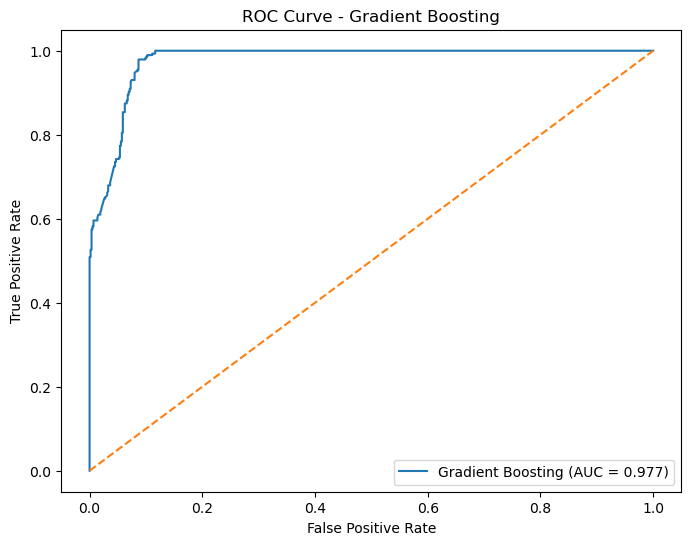

In [181]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

## Feature Importance

In [182]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

RFM_Total                     0.684855
Monetary                      0.128548
Frequency                     0.103710
Historical_CLV                0.038337
Purchase_Span_Days            0.019534
AOV                           0.012030
Avg_Days_Between_Purchases    0.007079
Total_Quantity                0.004552
Unique_Products               0.001356
dtype: float64


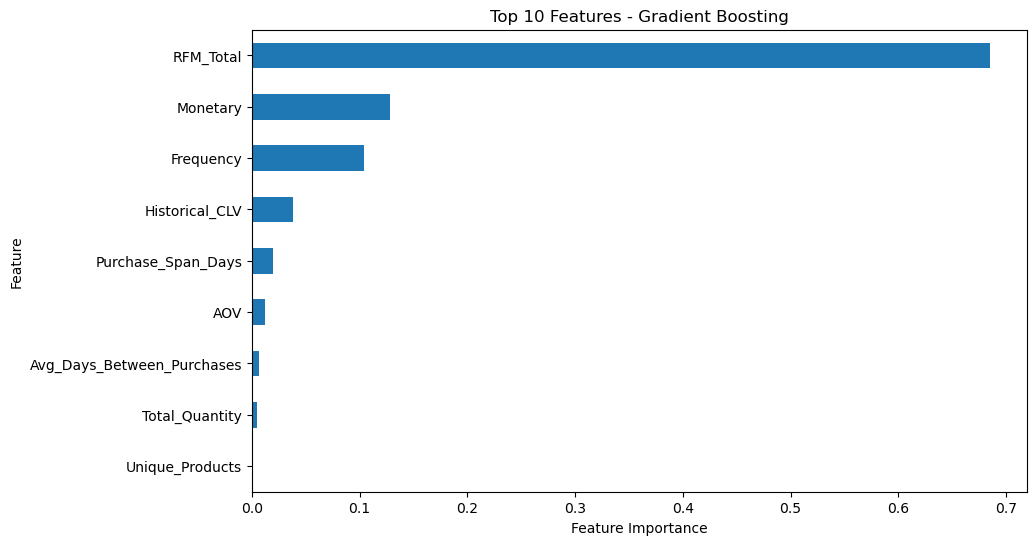

In [183]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features - Gradient Boosting")

plt.show()

* Current selected configuration:
    * Model: Gradient Boosting
        * Threshold: 0.40
        * Accuracy: 93.28%
        * Precision: 84.38%
        * Recall:97.91%
        * F1: 90.65%
        * ROC-AUC: 0.977

# Phase 13 — Churn Drivers

Phase 12 ne answer kiya: "Kaun churn karega?"

Phase 13 answer karega:"Customers churn kyun kar rahe hain?"

In [185]:
gb_model.feature_importances_

array([0.1037102 , 0.12854764, 0.01202992, 0.0045523 , 0.00135575,
       0.0195338 , 0.00707876, 0.68485508, 0.03833655])

In [186]:
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

RFM_Total                     0.684855
Monetary                      0.128548
Frequency                     0.103710
Historical_CLV                0.038337
Purchase_Span_Days            0.019534
AOV                           0.012030
Avg_Days_Between_Purchases    0.007079
Total_Quantity                0.004552
Unique_Products               0.001356
dtype: float64


In [187]:
top_features = feature_importance.head(10)

print("Top 10 Churn Drivers:")
print(top_features)

Top 10 Churn Drivers:
RFM_Total                     0.684855
Monetary                      0.128548
Frequency                     0.103710
Historical_CLV                0.038337
Purchase_Span_Days            0.019534
AOV                           0.012030
Avg_Days_Between_Purchases    0.007079
Total_Quantity                0.004552
Unique_Products               0.001356
dtype: float64


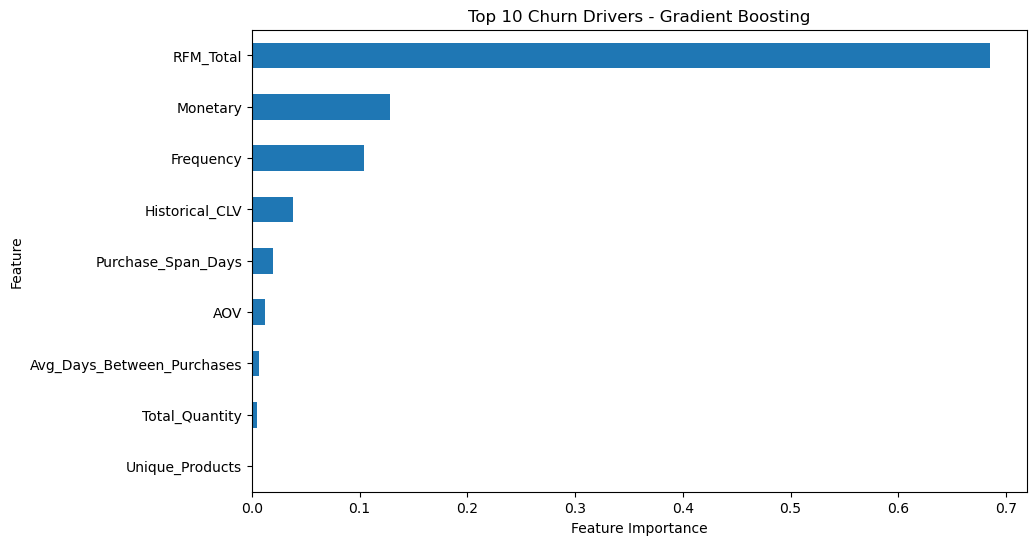

In [191]:
plt.figure(figsize=(10, 6))

top_features.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Churn Drivers - Gradient Boosting")

plt.show()

Model customer churn predict karte waqt overall RFM behaviour ko sabse zyada importance de raha hai.

RFM ka matlab:

* Recency → customer ne recently purchase kiya ya nahi
* Frequency → kitni frequently purchase karta hai
* Monetary → kitna spend karta hai


Second most important feature: Monetary = 12.85%

Matlab customer ka historical spending behaviour model ke churn prediction mein significant role play kar raha hai.

Business perspective:

High-value aur low-value customers ka churn risk model ke liye differently informative hai.

In [192]:
print(X_train.columns.tolist())

['Frequency', 'Monetary', 'AOV', 'Total_Quantity', 'Unique_Products', 'Purchase_Span_Days', 'Avg_Days_Between_Purchases', 'RFM_Total', 'Historical_CLV']


Abhi hum check karenge ki Active customers aur Churned customers ke behaviour mein actual difference kya hai.

Hum in features ko compare karenge:

Frequency

Monetary

AOV

Total Quantity

Unique Products

Purchase Span

Average Days Between Purchases

RFM Total

Historical CLV


# Behavioural Factors Analysis
1) Kya kar rahe hain?

Hum Active vs Churn customers ke average behaviour compare kar rahe hain.

In [193]:
# Combine test features and actual churn labels
analysis_df = X_test.copy()
analysis_df["Churn"] = y_test.values

# Compare average feature values by churn status
behavior_comparison = analysis_df.groupby("Churn").mean(numeric_only=True).T

behavior_comparison.columns = ["Active", "Churn"]

print(behavior_comparison)

                                 Active       Churn
Frequency                      5.263889    2.132404
Monetary                    2072.431043  684.266829
AOV                          374.706708  340.848453
Total_Quantity              1367.932292  428.958188
Unique_Products               75.855903   35.738676
Purchase_Span_Days           179.484375   57.376307
Avg_Days_Between_Purchases    58.869950   33.232772
RFM_Total                     10.008681    5.564460
Historical_CLV              2081.184342  688.200418


# Important Behavioural Factors
1) Kya karna hai?

Top 4 important features ka Active vs Churn distribution visualize karna hai:

* RFM_Total
* Monetary
* Frequency
* Historical_CLV

<Figure size 800x500 with 0 Axes>

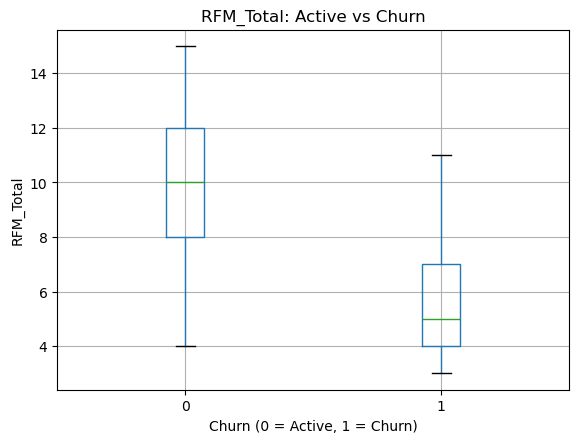

<Figure size 800x500 with 0 Axes>

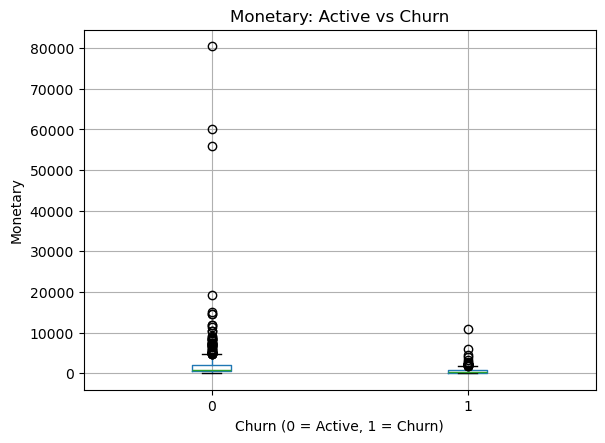

<Figure size 800x500 with 0 Axes>

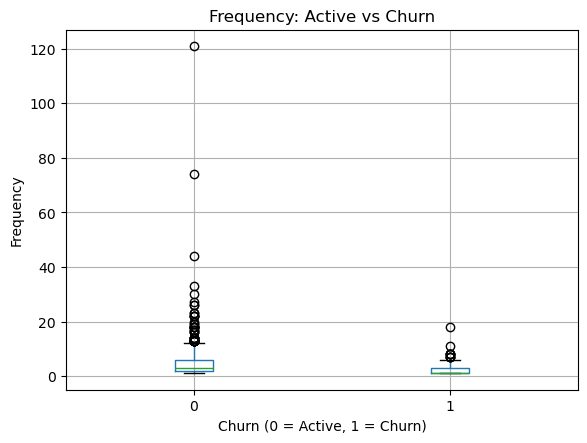

<Figure size 800x500 with 0 Axes>

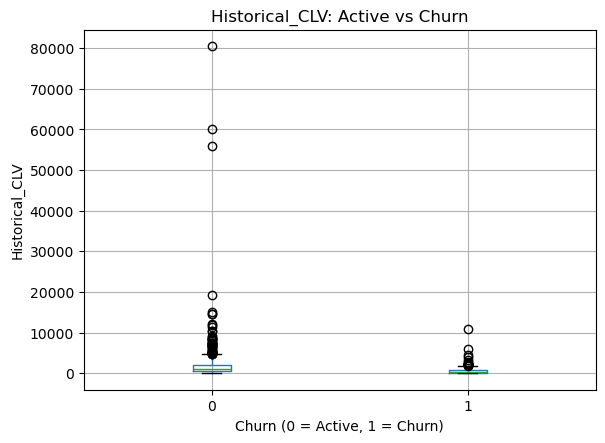

In [195]:
top_features = [
    "RFM_Total",
    "Monetary",
    "Frequency",
    "Historical_CLV"
]

for feature in top_features:
    plt.figure(figsize=(8, 5))

    analysis_df.boxplot(
        column=feature,
        by="Churn"
    )

    plt.title(f"{feature}: Active vs Churn")
    plt.suptitle("")
    plt.xlabel("Churn (0 = Active, 1 = Churn)")
    plt.ylabel(feature)

    plt.show()

### High-Risk Customers Identify Karna

In [196]:
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values
risk_df["Churn_Probability"] = gb_prob
risk_df["Predicted_Churn"] = gb_threshold_pred

risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[-0.01, 0.40, 0.70, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(risk_df["Risk_Level"].value_counts())

Risk_Level
Low Risk       530
High Risk      214
Medium Risk    119
Name: count, dtype: int64


In [200]:
risk_df.groupby("Risk_Level")["Actual_Churn"].mean()

C:\Users\kprsv\AppData\Local\Temp\ipykernel_17116\2181135474.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("Risk_Level")["Actual_Churn"].mean()


Risk_Level
Low Risk       0.011321
Medium Risk    0.722689
High Risk      0.911215
Name: Actual_Churn, dtype: float64

#### Business meaning: 
Model achhi tarah separate kar pa raha hai ki kaun likely churn karega aur kaun nahi. Risk buckets clearly meaningful hain (1% → 72% → 91% — clean increasing trend, koi overlap/confusion nahi).

In [211]:
risk_df["Customer ID"] = risk_df.loc[X_test.index, "Customer ID"]
risk_df[["Customer ID", "Actual_Churn", "Churn_Probability", "Risk_Level"]].head(10)

,Customer ID,Actual_Churn,Churn_Probability,Risk_Level
1713,16887.0,0,0.008943,Low Risk
4272,17377.0,0,0.040917,Low Risk
3917,13564.0,0,0.024677,Low Risk
590,16128.0,0,0.005047,Low Risk
3664,15353.0,0,0.744611,High Risk
56,18102.0,0,0.008943,Low Risk
0,13085.0,1,0.641243,Medium Risk
692,13394.0,0,0.055632,Low Risk
2319,NaN,0,0.035494,Low Risk
2912,17243.0,1,0.952795,High Risk


In [ ]:
## High-risk customer list

In [216]:
final_risk_list = (
    risk_df[
        risk_df["Risk_Level"].isin(["High Risk", "Medium Risk"])
    ][
        ["Customer ID", "Churn_Probability", "Actual_Churn", "Risk_Level"]
    ]
    .sort_values("Churn_Probability", ascending=False)
    .head(20)
    .copy()
)

final_risk_list["Churn_Probability"] = (
    final_risk_list["Churn_Probability"] * 100
).round(2)

final_risk_list

,Customer ID,Churn_Probability,Actual_Churn,Risk_Level
2072,NaN,98.81,1,High Risk
3362,16163.0,98.75,1,High Risk
2934,17345.0,98.72,1,High Risk
4203,15581.0,98.59,1,High Risk
1294,14654.0,98.49,1,High Risk
1015,13599.0,98.41,1,High Risk
1695,16887.0,98.41,1,High Risk
2648,NaN,98.41,1,High Risk
1442,15967.0,98.41,1,High Risk
1677,15984.0,98.32,1,High Risk


## Buisness Observation 
* 214 High Risk customers identified.
* High Risk group ka 91.12% actual churn rate hai.
* Medium Risk group ka 72.27% actual churn rate hai.
* Low Risk group ka sirf 1.13% actual churn rate hai.
* Most important behavioural signals: RFM_Total, Monetary, Frequency, Historical_CLV.
* High-risk customers generally lower-value and lower-engagement behaviour show karte hain.

# Phase 14 — Customer Risk Scoring

* Churn probability score use karenge
* Customers ko Low / Medium / High Risk mein segment karenge
* Risk segments ke liye retention actions define karenge
* Final customer-risk dashboard/table prepare karenge

### Risk Score Table

In [224]:
risk_score_table = risk_df[
    ["Churn_Probability", "Risk_Level", "Actual_Churn"]
].copy()

risk_score_table["Churn_Probability"] = (
    risk_score_table["Churn_Probability"] * 100
).round(2)

risk_score_table.head(10)

,Churn_Probability,Risk_Level,Actual_Churn
1713,0.89,Low Risk,0
4272,4.09,Low Risk,0
3917,2.47,Low Risk,0
590,0.50,Low Risk,0
3664,74.46,High Risk,0
56,0.89,Low Risk,0
0,64.12,Medium Risk,1
692,5.56,Low Risk,0
2319,3.55,Low Risk,0
2912,95.28,High Risk,1


### Risk Segment Summary

In [226]:
risk_summary = (
    risk_df.groupby("Risk_Level")
    .agg(
        Customers=("Actual_Churn", "count"),
        Actual_Churn_Rate=("Actual_Churn", "mean"),
        Avg_Churn_Probability=("Churn_Probability", "mean")
    )
    .round(3)
)

risk_summary

C:\Users\kprsv\AppData\Local\Temp\ipykernel_17116\2264430247.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("Risk_Level")


,Customers,Actual_Churn_Rate,Avg_Churn_Probability
Risk_Level,,,
Low Risk,530,0.011,0.047
Medium Risk,119,0.723,0.580
High Risk,214,0.911,0.901


## Business Action

| Risk               | Action                         |
| ------------------ | ------------------------------ |
| **High Risk**   | Immediate retention campaign   |
| **Medium Risk** | Targeted offer / re-engagement |
| **Low Risk**    | Normal engagement / loyalty    |


# Phase 16 — Interactive Dashboard

The final interactive dashboard was created using Julius AI.

https://evanescent-pelican-ua4.julius.site?utm_source=shared_artifact&ref=YPBE4QDHQADJ 

# Phase 17 — Final Business Insights

## 1. What is happening?

The analysis shows that active customers are more valuable and more engaged than churned customers.

Active customers generally:
- Purchase more often
- Spend more money
- Buy more products
- Have higher RFM scores
- Have higher historical CLV
- Stay connected with the business for a longer period

This shows that customer engagement and customer value are important for retention.

## 2. Why are customers churning?

The machine learning model shows that RFM-related behaviour is the strongest signal of churn.

The most important features were:

- RFM_Total — 68.49%
- Monetary — 12.85%
- Frequency — 10.37%
- Historical_CLV — 3.83%

This means customers with weaker purchase behaviour and lower customer value are more likely to be associated with churn.

These results show association, not direct cause and effect.

## 3. Which customers are at risk?

The customer risk analysis identified:

- High Risk — 214 customers
- Medium Risk — 119 customers
- Low Risk — 530 customers

The actual churn rates were:

- High Risk — 91.12%
- Medium Risk — 72.27%
- Low Risk — 1.13%

This shows a clear difference between the risk groups.

## 4. What should the business do?

### High-Risk Customers

The business should contact these customers quickly.

Possible actions:
- Send personalized offers
- Run win-back campaigns
- Give special discounts
- Focus on high-value customers

### Medium-Risk Customers

The business should try to stop these customers from becoming high risk.

Possible actions:
- Send reminder campaigns
- Recommend relevant products
- Offer limited-time deals
- Increase customer engagement

### Low-Risk Customers

These customers should be retained and encouraged to spend more.

Possible actions:
- Loyalty programs
- Cross-selling
- Upselling
- Referral programs

## 5. Overall Business Insight

The main finding of this project is that customer engagement and customer value are strongly linked with churn behaviour.

Customers with lower frequency, lower spending, weaker RFM scores and lower historical CLV show higher churn risk.

Therefore, the business should use a customer-risk-based retention strategy instead of treating all customers in the same way.

# Phase 18 — Final Conclusion

This project analyzed customer sales and behaviour to understand customer value, retention and churn.

The analysis covered data cleaning, exploratory analysis, RFM analysis, customer segmentation, SQL analysis, cohort analysis, CLV analysis and machine learning-based churn prediction.

The results showed that active customers generally have higher purchase frequency, spending, RFM scores and customer lifetime value compared with churned customers.

The Gradient Boosting model identified RFM_Total, Monetary, Frequency and Historical_CLV as the most important predictive features.

The risk analysis identified 214 high-risk customers, 119 medium-risk customers and 530 low-risk customers. The high-risk group had an actual churn rate of 91.12%, compared with 72.27% for medium-risk customers and only 1.13% for low-risk customers.

Based on these findings, the business should use different retention strategies for different customer groups. High-risk customers should receive immediate win-back actions, medium-risk customers should receive early engagement, and low-risk customers should be encouraged through loyalty and cross-selling activities.

Overall, this project shows how customer data, RFM analysis, machine learning and dashboarding can be combined to identify churn risk and support better customer retention decisions.